# Take-home Task: Job-Posting NLP Pipeline

## Overview

Build an NLP pipeline that processes job-posting data to extract insights about roles, skills, and job-market patterns.

The task assesses practical experience with:

- Text preprocessing and cleaning
- Embeddings and semantic similarity
- Text classification
- Basic retrieval-augmented generation (RAG)
- Evaluation methodology

**Expected effort:** approximately **6–8 hours**.
We value clean, well-reasoned code over a polished product. Document your decisions and trade-offs.

---

## Data

**Source:** [LinkedIn Job Postings – Kaggle](https://www.kaggle.com/datasets/arshkon/linkedin-job-postings)  
A pre-filtered sample of ~4,000 tech/data job postings is provided.

---

## Requirements

Complete the following four tasks in order. Each builds on the previous.

| Task | What | Deliverable |
|------|------|-------------|
| 1. Text preprocessing | Clean and prepare job descriptions for downstream NLP | Code + brief explanation of choices |
| 2. Role classification | Classify postings into role categories using the description text | Trained model + evaluation |
| 3. Embeddings & similarity | Embed job postings and implement semantic search | Working search function |
| 4. Evaluation & reflection | Assess quality and discuss limitations | Written analysis |

---

## 1. Text preprocessing

Clean and prepare the `description` field for downstream NLP tasks.

At minimum:

1. Explore the data: look at description length, missing values, duplicates, and any quality issues.
2. Implement a preprocessing pipeline that produces clean text suitable for embedding and classification.
3. Document your choices (what you removed, what you kept, and why).

Things to consider:
- HTML/markdown artefacts
- Boilerplate text (e.g. equal-opportunity statements)
- Very short or empty descriptions
- Duplicate content
- How preprocessing choices affect downstream tasks differently

---

## 2. Role classification

Build a classifier that predicts the **role category** of a job posting from its description text.

### Setup

The `role_category` column contains a pre-assigned label derived by keyword-matching on the `title` field:

| Category | Count |
|----------|------:|
| Software Engineer | 1,739 |
| Data Analyst | 890 |
| Data Scientist | 416 |
| DevOps / Cloud Engineer | 411 |
| Data Engineer | 401 |
| Machine Learning Engineer | 159 |
| Other | 56 |

Your classifier should predict `role_category` using only the `description` field (not the title).

### Task

1. Create train/test splits.
2. Train at least **two approaches** and compare them. For example:
   - TF-IDF + logistic regression (baseline)
   - Embedding-based classifier (e.g. embedding + simple NN, or fine-tuned model)
3. Evaluate with appropriate metrics (precision, recall, F1 — explain your choice of macro/micro/weighted).
4. Show a confusion matrix or per-class breakdown.
5. Discuss: which classes are hardest to distinguish and why?

---

## 3. Embeddings & similarity search

Create embeddings for the job postings and implement a semantic search function.

1. Choose an embedding model and justify your choice.
2. Embed the preprocessed job descriptions (or appropriate chunks).
3. Index them for efficient retrieval (e.g. FAISS, or brute-force cosine similarity for this dataset size).
4. Implement a search function that takes a natural-language query and returns the top-k most relevant postings.

Some suitable models from the `sentence-transformers` library:

- `all-MiniLM-L6-v2` — fast, lightweight (384 dims), good general-purpose baseline
- `all-mpnet-base-v2` — higher quality, larger (768 dims)
- `multi-qa-MiniLM-L6-cos-v1` — optimised for semantic search / question-answering

Pick one (or compare two) and explain your reasoning.

Demonstrate your search with at least **3 example queries**, e.g.:
- "machine learning engineer with NLP experience"
- "entry-level data analyst with SQL"
- "remote software engineer working on cloud infrastructure"

For each result, show the job title, company, and a short excerpt showing why it's relevant.

---

## 4. Evaluation & reflection

Write a brief section (in the notebook or a short markdown cell) covering:

1. **Classification errors:** Pick 2–3 misclassified examples from Task 2. Explain why the model likely got them wrong.
2. **Retrieval quality:** How would you measure whether your search returns relevant results? Propose a method (you don't need to fully implement it, but show your thinking).
3. **Limitations:** What are the main weaknesses of your pipeline? What would you improve with more time?

---

# Deliverables

Submit a GitHub repository or zipped project containing:

- This notebook (or equivalent scripts) with your solution;
- Dependency specification (`requirements.txt` or `pyproject.toml`);
- Reproducible setup instructions;
- Description of any API keys required.

---

# Notes

- A UI is not required.
- You may use any open-source libraries (scikit-learn, sentence-transformers, spaCy, etc.).
- If you use a pre-trained model, explain why you chose it.
- We care about your reasoning and methodology, not just the final numbers.
- If you run out of time, submit what you have with a note on what you'd do next.

---
## Data files

The following data files are provided in the `data/` directory:

| File | Rows | Description |
|------|-----:|-------------|
| `sample_postings.csv` | 4,072 | Job postings with title, description, company, location, salary, experience level, etc. |
| `sample_companies.csv` | 1,979 | Company profiles with name, description, size, location, and URL |
| `sample_skills.csv` | 6,800 | Skill tags linked to job postings (job_id → skill_abr) |
| `sample_skill_lookup.csv` | 35 | Skill abbreviation → full skill name mapping |
| `sample_industries.csv` | 422 | Industry labels (industry_id, industry_name) |

### Key columns

**sample_postings.csv:** `job_id`, `company_name`, `title`, `description`, `role_category`, `location`, `company_id`, `formatted_work_type`, `formatted_experience_level`, `skills_desc`, `max_salary`, `min_salary`, `remote_allowed`

**sample_companies.csv:** `company_id`, `name`, `description`, `company_size`, `state`, `country`, `city`, `url`

**sample_skills.csv:** `job_id`, `skill_abr`

**sample_skill_lookup.csv:** `skill_abr`, `skill_name` — maps abbreviations (e.g. `ENGR`) to full names (e.g. `Engineering`)

**sample_industries.csv:** `industry_id`, `industry_name`

---
## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("data")

# Load sample data
postings = pd.read_csv(DATA_DIR / "sample_postings.csv", low_memory=False)
print(f"Postings: {len(postings):,}")
print(f"Columns: {list(postings.columns)}")

Postings: 4,072
Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips', 'role_category']


In [2]:
# Load related tables
skills = pd.read_csv(DATA_DIR / "sample_skills.csv", low_memory=False) if (DATA_DIR / "sample_skills.csv").exists() else None
skill_lookup = pd.read_csv(DATA_DIR / "sample_skill_lookup.csv") if (DATA_DIR / "sample_skill_lookup.csv").exists() else None
companies = pd.read_csv(DATA_DIR / "sample_companies.csv", low_memory=False) if (DATA_DIR / "sample_companies.csv").exists() else None

if skills is not None:
    print(f"Skills entries: {len(skills):,}")
if skill_lookup is not None:
    print(f"Skill categories: {len(skill_lookup)}")
if companies is not None:
    print(f"Companies: {len(companies):,}")

Skills entries: 6,800
Skill categories: 35
Companies: 1,979


---
## Explore the data

In [3]:
postings.head(3)

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips,role_category
0,133130219,NaN,Software Engineer,"Education Bachelor's degree in software, math,...",NaN,NaN,Los Angeles Metropolitan Area,NaN,1.0,NaN,...,1.713535e+12,NaN,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN,Software Engineer
1,175485704,GOYT,Software Engineer,Job Description:GOYT is seeking a skilled and ...,NaN,NaN,"Denver, CO",76987056.0,273.0,NaN,...,1.713281e+12,NaN,0,PART_TIME,NaN,NaN,NaN,80202.0,8031.0,Software Engineer
2,2234533717,Ideando Inc,Full Stack Engineer,"Location: Remote\r\nCompany Overview:SkillFit,...",NaN,NaN,United States,69611476.0,21.0,NaN,...,1.713493e+12,NaN,0,FULL_TIME,NaN,NaN,NaN,NaN,NaN,Software Engineer


In [4]:
# Role distribution
postings["title"].value_counts().head(20)

title
Software Engineer                   181
Senior Software Engineer            164
Data Analyst                        137
Data Engineer                        91
Full Stack Engineer                  58
DevOps Engineer                      57
Data Scientist                       56
Senior Data Engineer                 44
Cloud Engineer                       32
Embedded Software Engineer           30
Senior Data Analyst                  25
Machine Learning Engineer            23
Principal Software Engineer          21
Senior Data Scientist                21
Lead Software Engineer               20
Online Data Analyst                  20
Software Engineer in Test            20
Staff Software Engineer              19
Senior Machine Learning Engineer     19
Java Software Engineer               16
Name: count, dtype: int64

In [5]:
# Check description field
print(f"Postings with description: {postings['description'].notna().sum():,}")
print(f"\nSample description (first 500 chars):")
print(postings['description'].dropna().iloc[0][:500])

Postings with description: 4,072

Sample description (first 500 chars):
Education Bachelor's degree in software, math, or science required Job Skills Analytical skills, group work, knowledge of intended audience, understanding of different roles


---
## Your work starts here

Use the cells above as a starting point. Add new cells below to build your solution.

-----------------

# TASK 1 - Text Preprocessing

In [6]:
# Other imports

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from IPython.display import display # ensure display() is available
import unicodedata
import re

## 01. Data overview

Before looking at the job descriptions, I'll first check the provided files, the main modelling table, and the relationships between datasets.

Each row in `sample_postings.csv` represents one job posting. The related company and skill tables are useful for understanding the data, but they are not treated as model features at this stage.

In [7]:
industries = pd.read_csv(DATA_DIR / "sample_industries.csv")

datasets = {
    "Postings": postings,
    "Companies": companies,
    "Skills": skills,
    "Skill lookup": skill_lookup,
    "Industries": industries,
}

dataset_summary = pd.DataFrame(
    {
        "rows": {name: len(data) for name, data in datasets.items()},
        "columns": {name: data.shape[1] for name, data in datasets.items()},
    }
)

dataset_summary

,rows,columns
Postings,4072,32
Companies,1979,10
Skills,6800,2
Skill lookup,35,2
Industries,422,2


In [8]:
main_columns = [
    "job_id",
    "title",
    "description",
    "role_category",
    "company_id",
    "company_name",
]

postings_summary = pd.DataFrame(
    {
        "dtype": postings[main_columns].dtypes.astype(str),
        "missing": postings[main_columns].isna().sum(),
        "unique": postings[main_columns].nunique(),
    }
)

postings_summary

,dtype,missing,unique
job_id,int64,0,4072
title,str,0,2326
description,str,0,3628
role_category,str,0,7
company_id,float64,37,1979
company_name,str,37,1975


In [9]:
relationship_checks = pd.Series(
    {
        "Posting IDs are unique": postings["job_id"].is_unique,
        "Company IDs are unique": companies["company_id"].is_unique,
        "Skill lookup codes are unique": skill_lookup["skill_abr"].is_unique,
        "Skill rows without a matching posting": (
            ~skills["job_id"].isin(postings["job_id"])
        ).sum(),
        "Postings without skill records": (
            ~postings["job_id"].isin(skills["job_id"])
        ).sum(),
        "Postings with an unmatched company ID": (
            postings["company_id"].notna()
            & ~postings["company_id"].isin(companies["company_id"])
        ).sum(),
        "Skill codes without a lookup value": (
            ~skills["skill_abr"].isin(skill_lookup["skill_abr"])
        ).sum(),
    },
    name="result",
)

relationship_checks.to_frame()

,result
Posting IDs are unique,True
Company IDs are unique,True
Skill lookup codes are unique,True
Skill rows without a matching posting,0
Postings without skill records,131
Postings with an unmatched company ID,0
Skill codes without a lookup value,0


### Initial observations

The postings table contains 4072 rows, all with unique job_id.

The target contains seven categories, and every posting has at least a title, description and target label.

We can also notice there are fewer unique descriptions than postings, indicating there are **some duplicate descriptions** that will need to be investigated.

Besides that, we can see the company and skills relationships are mostly complete (all available company IDs and skill codes have matching records). However, there are 37 postings without company info and 131 without skill records.

## 02. Target distribution

The target classes were derived from job titles (weak supervision) so they should be treated as weak labels rather than perfect ground truth. 

Let's first check their size and balance, as this will affect the strategies for splitting and the choice of evaluation metrics.

role_category,count,proportion
Software Engineer,1739,42.7%
Data Analyst,890,21.9%
Data Scientist,416,10.2%
DevOps / Cloud Engineer,411,10.1%
Data Engineer,401,9.8%
Machine Learning Engineer,159,3.9%
Other,56,1.4%


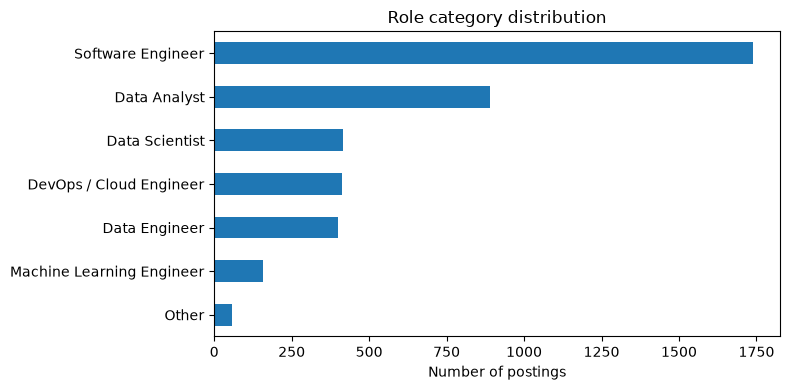

In [10]:
role_distribution = (
    postings["role_category"]
    .value_counts()
    .rename_axis("role_category")
    .reset_index(name="count")
)

role_distribution["proportion"] = (
    role_distribution["count"] / len(postings)
)

display(
    role_distribution.style
    .format({"proportion": "{:.1%}"})
    .hide(axis="index")
)

ax = role_distribution.plot.barh(
    x="role_category",
    y="count",
    legend=False,
    figsize=(8, 4),
)

ax.set_title("Role category distribution")
ax.set_xlabel("Number of postings")
ax.set_ylabel("")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

The dataset is clearly imbalanced. `Software Engineer` represents 42.7% of the postings, while `Machine Learning Engineer` represents 3.9% and `Other` only 1.4%.

This means accuracy alone could hide poor performance on the smaller categories. So **stratification** (preserving approx. the same proportion in every subset) and **class-sensitive metrics** (such as macro F1) will be important, as they **help account for class imbalance** during splitting and evaluation.

I will use macro F1 as the main model-selection metric, since it gives each category equal importance, while also reporting weighted F1 and accuracy for context.

I do not report micro F1 separately because, for this single-label multiclass problem, it is equivalent to accuracy.

### Evaluation 

The idea for the evaluation design is to use 80% of the data for development (train + validation) and keep 20% as an untouched final test set. 

Within the development data, I intend to use 5-fold stratified cross-validation. The goal of it is to have a more reliable model comparison over having a fixed train/validation/test split.

## 03. Description availability and length

Before deciding how to clean the descriptions, let's check whether they are usable and how much their length varies.

In [12]:
description_audit = postings[
    ["job_id", "title", "role_category", "description"]
].copy()

description_audit["char_count"] = (
    description_audit["description"].str.len()
)

description_audit["word_count"] = (
    description_audit["description"].str.split().str.len()
)

# Create a compact description preview version for displaying examples.
description_audit["description_preview"] = (
    description_audit["description"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 250)
)

description_quality = pd.Series(
    {
        "Missing descriptions": postings["description"].isna().sum(),
        "Non-string descriptions": (
            postings["description"].notna()
            & ~postings["description"].map(
                lambda value: isinstance(value, str)
            )
        ).sum(),
        "Empty or whitespace-only descriptions": (
            postings["description"].map(
                lambda value: isinstance(value, str)
                and not value.strip()
            )
        ).sum(),
    },
    name="count",
)

display(description_quality.to_frame())

length_summary = (
    description_audit[["char_count", "word_count"]]
    .quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1])
    .rename_axis("quantile")
)

display(length_summary)

,count
Missing descriptions,0
Non-string descriptions,0
Empty or whitespace-only descriptions,0


,char_count,word_count
quantile,,
0.00,41.00,1.00
0.01,304.81,40.00
0.05,685.55,94.00
0.25,1898.75,253.00
0.50,3641.00,488.50
0.75,5423.50,755.00
0.95,7868.00,1113.00
0.99,9722.92,1350.29
1.00,17868.00,2486.00


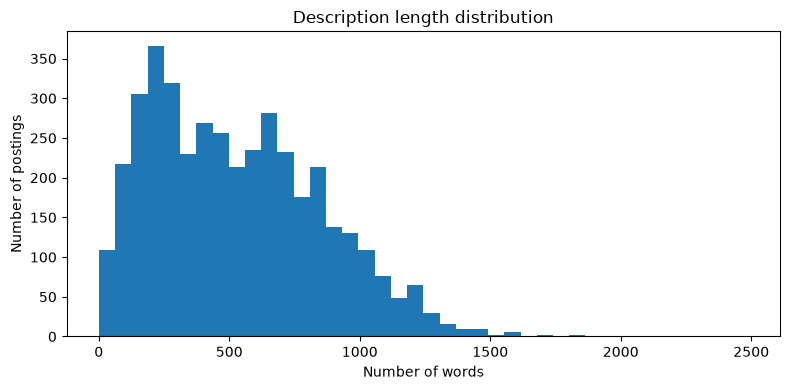

title,role_category,char_count,word_count,description_preview
Senior Software Engineer,Software Engineer,47,1,https://boomi.com/boomi-jobs/?gh_jid=5149123004
Data Analyst or Data Product Manager (Native US Citizens Only),Data Analyst,41,4,Skill Sets: SparkPyspark.TableauSQL Query
Software Engineer,Software Engineer,100,11,Cryptography developer for digital cash cryptosystem. Universal crypto transactions in milliseconds.
Senior Data Analyst,Data Analyst,107,16,"Must have : Data Analyst: with Big Query, and SQL.Must Have Skills:2 intermediate analytics skills (BQ/SQL)"
Software Engineer in Test,Software Engineer,98,19,"Must be local and ex-AMEX only Must be strong in React, Java, Selenium, and BDD Any visa is fine"
Data Engineer,Data Engineer,150,21,SQL (expert)Snowflake - not a roadblock (added advantage)Cloud - AWS is preferred (exp on any cloud)Python – intermediateDatabricks - added advantage.
Full Stack Engineer,Software Engineer,248,21,Javascript/TypescriptNode.jsVueJS/React/Angular or similarAWS experienceCI/CD a plusWorkDay/eTime experience is a huge plusJavascript/TypescriptNode.jsVueJS/React/Angular or similarAWS experienceCI/CD a plusWorkDay/eTime experience is a huge plus
Java full stack developer with react - W2,Software Engineer,169,21,"immediate hiring for H1T, W2 Title: Java Full Stack with React expLocation: Dallas, TX (only locals) Regards and ThanksCrystalLead IT RecruiterCrystal@americanunit.com"
Software Engineer,Software Engineer,173,23,"Education Bachelor's degree in software, math, or science required Job Skills Analytical skills, group work, knowledge of intended audience, understanding of different roles"
Embedded Software Engineer,Software Engineer,218,23,"Embedded Software Engineer Location: Spring, TX – Onsite RoleDuration: Long Term ProjectSkills:Embedded SoftwareScripting like c, PythonCommon Protocols – iSCSI, UART, SPIMicro controllerARMAnalysersFW DevelopmentUEFI"


In [13]:
ax = description_audit["word_count"].plot.hist(
    bins=40,
    figsize=(8, 4),
)

ax.set_title("Description length distribution")
ax.set_xlabel("Number of words")
ax.set_ylabel("Number of postings")

plt.tight_layout()
plt.show()

# Look through the shortest descriptions (fewer word counts)
shortest_descriptions = (
    description_audit
    .drop_duplicates("description")
    .nsmallest(10, "word_count")
)

display(
    shortest_descriptions[
        [
            "title",
            "role_category",
            "char_count",
            "word_count",
            "description_preview",
        ]
    ].style.hide(axis="index")
)

In [14]:
# Check whether any description contains only a URL.
url_only_mask = (
    postings["description"]
    .str.strip()
    .str.fullmatch(
        r"(?:https?://|www\.)\S+",
        case=False,
        na=False,
    )
)

url_only_descriptions = postings.loc[
    url_only_mask,
    [
        "job_id",
        "title",
        "role_category",
        "description",
    ],
]

print(
    f"URL-only descriptions: "
    f"{len(url_only_descriptions)}"
)

display(
    url_only_descriptions.style.hide(axis="index")
)

URL-only descriptions: 1


job_id,title,role_category,description
3884839409,Senior Software Engineer,Software Engineer,https://boomi.com/boomi-jobs/?gh_jid=5149123004


**All postings** contain a **non-empty description**, but **their length varies considerably**.

The median description has around 489 words, while 5% have fewer than 94 words. There is also a long upper tail, with the longest description reaching almost 2,500 words.

One record contains only a URL and does not provide usable description text for the classifier, so it should be excluded during data preparation. The other short descriptions still contain potentially useful technical information.

Apart from the URL-only case, length alone does not provide a defensible cutoff for removing records.

## 04. Text formatting

Job descriptions often contain HTML, links and copied formatting. Before deciding what should be cleaned, let's check which of these patterns are actually present in this dataset.

In [15]:
format_patterns = {
    # Matches common opening and closing HTML tags:
    # </? allows either "<tag>" or "</tag>",
    # [A-Za-z] requires the tag name to begin with a letter,
    # and [^>]* matches the rest of the tag until ">".
    "HTML tags": r"</?[A-Za-z][^>]*>",
    
    # Matches the main forms of HTML entities:
    # named entities such as &amp;,
    # decimal codes such as &#39;,
    # and hexadecimal codes such as &#x27;.
    "HTML entities": r"&(?:[a-zA-Z]+|#\d+|#x[0-9a-fA-F]+);",
    
    # Links beginning with http, https or www.
    "URLs": r"(?:https?://|www\.)\S+",
    
    # Explicit new-line characters like '\n' or '\r'.
    "Line breaks": r"[\r\n]",
    
    # Matches two or more consecutive spaces or tab characters.
    "Repeated spaces or tabs": r"[ \t]{2,}",
    
    # (?m) makes ^ check the start of every line.
    # The rest matches headings such as "# Title" or "### Requirements".
    "Markdown-like headings": r"(?m)^\s*#{1,6}\s+\S",
    
    # Matches lines beginning with "-", "*" or "•",
    # followed by some text.
    "Markdown-like bullets": r"(?m)^\s*[-*•]\s+\S",
    
    # Matches ASCII control-character ranges, excluding normal
    # tabs and line breaks, plus common Unicode zero-width characters.
    "Invisible or control characters": (
        r"[\x00-\x08\x0B\x0C\x0E-\x1F\x7F-\x9F"
        r"\u200B\u200C\u200D\u2060\uFEFF]"
    ),
}

format_summary = (
    pd.Series(
        {
            issue: postings["description"]
            .str.contains(pattern, regex=True)
            .sum()
            for issue, pattern in format_patterns.items()
        },
        name="count",
    )
    .rename_axis("issue")
    .reset_index()
)

format_summary["proportion"] = (
    format_summary["count"] / len(postings)
)

display(
    format_summary.style
    .hide(axis="index")
    .format({"proportion": "{:.1%}"})
)

issue,count,proportion
HTML tags,0,0.0%
HTML entities,5,0.1%
URLs,651,16.0%
Line breaks,3829,94.0%
Repeated spaces or tabs,712,17.5%
Markdown-like headings,3,0.1%
Markdown-like bullets,104,2.6%
Invisible or control characters,38,0.9%


The descriptions are generally clean. There are no HTML tags, while HTML entities and Markdown-like formatting are rare. Most descriptions contain line breaks, which is to be expected from job postings.

The preprocessing will therefore remain conservative:

* decode the small number of HTML entities;
* replace URLs inside otherwise useful descriptions with `[URL]`;
* replace invisible characters and repeated whitespace with spaces;
* preserve casing and punctuation.

Punctuation is kept because it carries meaning in technical terms such as `C++`, `C#`, `.NET`, `CI/CD` and `Node.js`.

## 05. Exact duplicates

As mentioned before, there are fewer unique descriptions than postings, so some descriptions appear more than once.

Before deciding whether these are duplicates that should be removed, I want to understand how many postings are affected, how large the repeated groups are, and whether they share the same labels, titles and companies.

In [16]:
description_counts = postings["description"].value_counts()
duplicate_description_counts = description_counts[
    description_counts > 1
]

duplicate_postings = (
    postings[
        [
            "job_id",
            "title",
            "role_category",
            "company_name",
            "description",
        ]
    ]
    .assign(
        group_size=lambda data: (
            data.groupby("description")["job_id"].transform("size")
        )
    )
    .query("group_size > 1")
)

duplicate_groups = (
    duplicate_postings
    .groupby("description")
    .agg(
        group_size=("job_id", "size"),
        role_categories=("role_category", "nunique"),
    )
    .reset_index()
)

duplicate_summary = pd.DataFrame(
    {
        "metric": [
            "Exact duplicate groups",
            "Postings in duplicate groups",
            "Label-consistent groups",
            "Conflicting-label groups",
            "Rows removed by description + label deduplication",
        ],
        "value": [
            len(duplicate_groups),
            int(duplicate_description_counts.sum()),
            int(duplicate_groups["role_categories"].eq(1).sum()),
            int(duplicate_groups["role_categories"].gt(1).sum()),
            int(
                postings.duplicated(
                    subset=["description", "role_category"]
                ).sum()
            ),
        ],
    }
)

display(duplicate_summary.style.hide(axis="index"))

duplicate_share = (
    duplicate_description_counts.sum() / len(postings)
)

print(
    f"{duplicate_share:.1%} of postings belong to an exact duplicate group.\n"
)

conflicting_descriptions = duplicate_groups.loc[
    duplicate_groups["role_categories"].gt(1),
    "description",
]

conflicting_group_summary = (
    duplicate_postings.loc[
        duplicate_postings["description"].isin(
            conflicting_descriptions
        )
    ]
    .groupby("description")
    .agg(
        postings=("job_id", "size"),
        labels=(
            "role_category",
            lambda values: " | ".join(
                sorted(values.unique())
            ),
        ),
    )
    .reset_index()
)

conflicting_group_summary["description preview"] = (
    conflicting_group_summary["description"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 240)
    .add("...")
)

display(
    conflicting_group_summary[
        [
            "postings",
            "labels",
            "description preview",
        ]
    ]
    .style
    .hide(axis="index")
)

metric,value
Exact duplicate groups,196
Postings in duplicate groups,640
Label-consistent groups,194
Conflicting-label groups,2
Rows removed by description + label deduplication,442


15.7% of postings belong to an exact duplicate group.



postings,labels,description preview
14,Data Analyst | Data Scientist,The ideal candidate will use their passion for big data and analytics to provide insights to the business covering a range of topics. They will be responsible for conducting both recurring and ad hoc analysis for business users. Responsibil...
3,Data Scientist | Machine Learning Engineer,"hackajob transforms your job search into a personalized experience, where you're in control. We align your skills, salary expectations, and location preferences to deliver tailored opportunities. Experience the power of being matched to IT ..."


### Conflicting labels

Only two exact-description groups contain more than one target label, so I inspected both of them.

These cases are especially important because the classifier would receive exactly the same input text with different expected outputs.

In [17]:
conflicting_descriptions = duplicate_groups.loc[
    duplicate_groups["role_categories"] > 1,
    "description",
]

for group_number, description in enumerate(
    conflicting_descriptions,
    start=1,
):
    group = (
        duplicate_postings.loc[
            duplicate_postings["description"].eq(description),
            [
                "job_id",
                "title",
                "role_category",
                "company_name",
            ],
        ]
        .sort_values(["role_category", "title"])
    )

    # Show the shared description once instead of repeating it
    # for every posting in the group.
    description_preview = " ".join(description.split())

    # if len(description_preview) > 300:
    #     description_preview = (
    #         f"{description_preview[:]}..."
    #     )

    print(
        f"Conflicting group {group_number}: "
        f"{len(group)} postings"
    )
    print(
        f"Description preview: "
        f"{description_preview}\n"
    )

    display(
        group.style.hide(axis="index")
    )

Conflicting group 1: 14 postings
Description preview: The ideal candidate will use their passion for big data and analytics to provide insights to the business covering a range of topics. They will be responsible for conducting both recurring and ad hoc analysis for business users. ResponsibilitiesUnderstand the day-to-day issues that our business faces, which can be better understood with data Compile and analyze data related to business' issues Develop clear visualizations to convey complicated data in a straightforward fashion QualificationsBachelor's or Master's degree in Statistics or Applied Mathematics or equivalent experience 1 - 2 years' Data Analysis experience Proficient in SQL



job_id,title,role_category,company_name
3895242027,Data Analyst,Data Analyst,Coders Data
3901457333,Data Analyst,Data Analyst,Coders Data
3901461025,Data Analyst,Data Analyst,Coders Data
3904389545,Data Analyst,Data Analyst,Coders Data
3885109955,Data Analyst/Data Science/NLP (Intern apr 30) DIN01,Data Scientist,Data Glacier
3890895123,Data Science Intern DIN17,Data Scientist,Data Glacier
3891075442,Data Science Intern DIN18,Data Scientist,Data Glacier
3891278079,Data Science Intern DIN19,Data Scientist,Data Glacier
3885110673,Data Science intern ( Apr 30) -DIN01,Data Scientist,Data Glacier
3891070831,Data Science intern -DIN17,Data Scientist,Data Glacier


Conflicting group 2: 3 postings
Description preview: hackajob transforms your job search into a personalized experience, where you're in control. We align your skills, salary expectations, and location preferences to deliver tailored opportunities. Experience the power of being matched to IT roles across various industries throughout the United States, ensuring your career journey is uniquely yours. We have plenty of opportunities at the moment for AI/ML Engineer/Data Scientist preferred experience within industries such as defense, intelligence, aerospace, government contracting, and related fields. The AI/ML Engineer/Data Scientist will be responsible for developing algorithms, scripting, building predictive analytics, automating processes, and applying machine learning techniques. They will utilize a variety of tools and frameworks to transform data into actionable insights that aid senior leadership in making informed decisions. Working closely with customer management, project man

job_id,title,role_category,company_name
3905875652,Data Scientist,Data Scientist,hackajob
3905875688,Data Scientist,Data Scientist,hackajob
3905881936,Machine Learning Engineer,Machine Learning Engineer,hackajob


Most exact duplicate groups have consistent labels: 194 of the 196 groups contain only one role category. The remaining two descriptions appear with more than one label, showing that the expected role cannot always be determined from the description alone.

**For modelling:**

* repeated rows with the same description and label will be deduplicated;
* keep cases where the same description has different labels;
* all rows sharing the same description will stay in the same dataset partition.

The last rule prevents identical text from appearing in both training and evaluation data.

## Data audit summary

Overall, the descriptions look usable. The two main things I need to account for are the class imbalance and the repeated descriptions.

I will remove the one record that contains only a URL, but I will not apply a general minimum-length rule because some of the shorter descriptions are still informative.

Based on the audit, I will:

* keep the cleaning conservative and preserve meaningful technical punctuation;
* keep one row per unique `description` and `role_category` combination;
* keep identical descriptions in the same dataset split;
* preserve the class proportions as much as possible and use macro F1 as the main model-selection metric.

There may still be lightly edited reposts, shared boilerplate and some ambiguity in the title-based labels. However, due to time constraints, I'll not go into more detail.

## 06. Preparing the modelling data

From the audit, we figured out we should do the following cleaning steps:

* decode the few HTML entities;
* fix the one broken apostrophe pattern found;
* replace URLs inside otherwise useful descriptions with `[URL]`;
* replace the invisible characters found in the audit with spaces;
* turn line breaks, tabs and repeated whitespace into single spaces.

I am keeping the cleaning conservative because the descriptions are already mostly usable. Case and punctuation are left unchanged so terms such as `C++`, `C#`, `.NET`, `CI/CD` and `Node.js` are preserved.

The one description made up only of a URL is removed before cleaning. For the remaining descriptions, `[URL]` keeps the sentence readable without retaining domain names and paths that are unlikely to help identify the role.

Any lowercasing or tokenization needed for TF-IDF will be handled later inside its own pipeline.

In [18]:
import sys

# The package is inside src/, so add that folder to Python's import path.
sys.path.insert(0, str(Path("src").resolve()))

from job_posting_nlp.preprocessing import (
    clean_description,
    prepare_modeling_rows,
)

### Cleaning examples

The table below uses the first matching description in dataset order for three of the less obvious cleaning changes.

In [19]:
example_patterns = {
    "HTML entity": format_patterns["HTML entities"],
    "URL": format_patterns["URLs"],
    "Broken apostrophe": re.escape("â\x80\x99"),
}

cleaning_examples = []

for issue, pattern in example_patterns.items():
    match_mask = postings["description"].str.contains(
        pattern,
        regex=True,
        na=False,
    )

    # For URLs, skip the unusable URL-only row and show one inside useful text.
    if issue == "URL":
        match_mask &= ~url_only_mask

    description = postings.loc[
        match_mask,
        "description",
    ].iloc[0]

    match = re.search(pattern, description)
    start = max(0, match.start() - 80)
    end = min(len(description), match.end() + 80)

    before = description[start:end].strip()
    prefix = "..." if start > 0 else ""
    suffix = "..." if end < len(description) else ""
    before = f"{prefix}{before}{suffix}"

    cleaning_examples.append(
        {
            "issue": issue,
            # Make the control characters in the broken apostrophe visible.
            "before": (
                before
                .replace("\x80", r"\x80")
                .replace("\x99", r"\x99")
            ),
            "after": clean_description(before),
        }
    )

display(
    pd.DataFrame(cleaning_examples)
    .style
    .hide(axis="index")
    .set_properties(
        subset=["before", "after"],
        **{
            "white-space": "pre-wrap",
            "text-align": "left",
        },
    )
    .format(escape="html")
)

issue,before,after
HTML entity,"...ata and analytics, business administration or related study. Experience 4&plus; years of experience in data Experience in implementing and/or working within a...","...ata and analytics, business administration or related study. Experience 4+ years of experience in data Experience in implementing and/or working within a..."
URL,"...ve technology solutions. We highly encourage you to explore our beta product at https://skillfitai.com/ before submitting your application, allowing you to gain a deeper understanding...","...ve technology solutions. We highly encourage you to explore our beta product at [URL] before submitting your application, allowing you to gain a deeper understanding..."
Broken apostrophe,"...is no better time to join our rapidly growing team at Oak Street Health. We canâ\x80\x99t think of a mission any more motivating; and, with your help, we can drive chan...","...is no better time to join our rapidly growing team at Oak Street Health. We can't think of a mission any more motivating; and, with your help, we can drive chan..."


### Preparing the modelling rows

After cleaning, repeated rows with the same cleaned description and role category are removed.

The role category is included in the deduplication key because the audit found descriptions with more than one observed label. This keeps those cases instead of silently choosing one label.

In [20]:
# These rows are also reused later to build the retrieval corpus.
cleaned_rows = postings.loc[~url_only_mask].copy()
cleaned_rows["cleaned_description"] = (
    cleaned_rows["description"].map(clean_description)
)

cleaned_description_counts = (
    cleaned_rows["cleaned_description"].value_counts()
)

modeling_rows = prepare_modeling_rows(postings)

conflicting_label_descriptions = (
    modeling_rows
    .groupby("cleaned_description")["role_category"]
    .nunique()
    .gt(1)
    .sum()
)

preparation_summary = pd.DataFrame(
    {
        "metric": [
            "Original postings",
            "URL-only descriptions removed",
            "Unique cleaned descriptions",
            "Prepared modelling rows",
            "Conflicting-label descriptions retained",
        ],
        "value": [
            len(postings),
            int(url_only_mask.sum()),
            modeling_rows["cleaned_description"].nunique(),
            len(modeling_rows),
            int(conflicting_label_descriptions),
        ],
    }
)

display(preparation_summary.style.hide(axis="index"))

prepared_role_distribution = (
    modeling_rows["role_category"]
    .value_counts()
    .rename_axis("role_category")
    .reset_index(name="count")
)

prepared_role_distribution["proportion"] = (
    prepared_role_distribution["count"] / len(modeling_rows)
)

display(
    prepared_role_distribution.style
    .hide(axis="index")
    .format({"proportion": "{:.1%}"})
)

metric,value
Original postings,4072
URL-only descriptions removed,1
Unique cleaned descriptions,3622
Prepared modelling rows,3624
Conflicting-label descriptions retained,2


role_category,count,proportion
Software Engineer,1543,42.6%
Data Analyst,785,21.7%
DevOps / Cloud Engineer,384,10.6%
Data Engineer,366,10.1%
Data Scientist,353,9.7%
Machine Learning Engineer,142,3.9%
Other,51,1.4%


### Prepared data

After removing the URL-only record and applying the cleaning, the dataset contains 3,622 unique cleaned descriptions.

Deduplicating by cleaned description and role category results in 3,624 modelling rows. The additional two rows come from the descriptions with conflicting labels, which remain represented under both observed categories.

The class imbalance remains mostly unchanged, with `Software Engineer` accounting for 42.6% of the prepared data and `Other` only 1.4%.

`cleaned_description` will be the classifier input, while the original description and identifiers are kept for later diagnostics. The data is now ready for a grouped split using the cleaned description as the grouping key.

# TASK 2 - Role Classification

## 07. Evaluation setup

For the evaluation, I want to keep 20% of the data completely untouched until the end (test set), and use the other 80% for building and comparing the models (development set).

The main thing to be careful about is that the same cleaned description cannot end up on both sides of the split. A normal 80/20 split does not guarantee that, so I use `StratifiedGroupKFold` with five folds and take the first fold as the test set.

Since one out of five folds is around 20%, this gives us the 80/20 split while also keeping repeated descriptions together and preserving the class balance as much as possible.

This means I use five folds twice, but for two different reasons:

* first, on the full data, only to create the 80/20 development-test split;
* then, only inside the development data, to compare the models through cross-validation.

I use a fixed seed of 42 so the splits are always the same. The test set is put aside now and will only be used after the model selection is finished.

In [21]:
from job_posting_nlp.evaluation import (
    create_development_test_split,
    make_grouped_cv,
)

development_rows, test_rows = create_development_test_split(
    modeling_rows
)

X_development = development_rows["cleaned_description"]
y_development = development_rows["role_category"]
development_groups = development_rows["cleaned_description"]

X_test = test_rows["cleaned_description"]
y_test = test_rows["role_category"]
test_groups = test_rows["cleaned_description"]

cv_splitter = make_grouped_cv()
cv_folds = list(
    cv_splitter.split(
        X_development,
        y=y_development,
        groups=development_groups,
    )
)

In [22]:
class_order = (
    modeling_rows["role_category"]
    .value_counts()
    .index
)

partition_summary = pd.DataFrame(
    {
        "partition": ["Development", "Test"],
        "rows": [len(development_rows), len(test_rows)],
        "share": [
            len(development_rows) / len(modeling_rows),
            len(test_rows) / len(modeling_rows),
        ],
        "unique descriptions": [
            development_groups.nunique(),
            test_groups.nunique(),
        ],
    }
)

holdout_distribution = pd.DataFrame(
    {
        "role category": class_order,
        "prepared": (
            modeling_rows["role_category"]
            .value_counts(normalize=True)
            .reindex(class_order)
            .to_numpy()
        ),
        "development": (
            y_development
            .value_counts(normalize=True)
            .reindex(class_order)
            .to_numpy()
        ),
        "test": (
            y_test
            .value_counts(normalize=True)
            .reindex(class_order)
            .to_numpy()
        ),
    }
)

holdout_distribution["test difference (pp)"] = (
    (
        holdout_distribution["test"]
        - holdout_distribution["prepared"]
    )
    * 100
)

description_overlap = len(
    set(development_groups) & set(test_groups)
)

assert description_overlap == 0

display(
    partition_summary.style
    .hide(axis="index")
    .format({"share": "{:.1%}"})
)

display(
    holdout_distribution.style
    .hide(axis="index")
    .format(
        {
            "prepared": "{:.1%}",
            "development": "{:.1%}",
            "test": "{:.1%}",
            "test difference (pp)": "{:+.2f}",
        }
    )
)

print(
    "Cleaned-description overlap between "
    f"development and test: {description_overlap}"
)

conflicting_cleaned_descriptions = (
    modeling_rows
    .groupby("cleaned_description")["role_category"]
    .nunique()
    .loc[lambda counts: counts.gt(1)]
    .index
)

conflicting_rows = modeling_rows.loc[
    modeling_rows["cleaned_description"].isin(
        conflicting_cleaned_descriptions
    ),
    [
        "cleaned_description",
        "role_category",
    ],
].copy()

conflicting_rows["partition"] = np.where(
    conflicting_rows.index.isin(test_rows.index),
    "Test",
    "Development",
)

assert (
    conflicting_rows
    .groupby("cleaned_description")["partition"]
    .nunique()
    .eq(1)
    .all()
), "A conflicting-label description was split across partitions."

conflicting_group_locations = (
    conflicting_rows
    .groupby("cleaned_description", sort=False)
    .agg(
        partition=("partition", "first"),
        labels=(
            "role_category",
            lambda labels: ", ".join(sorted(labels)),
        ),
    )
    .reset_index(drop=True)
)

conflicting_group_locations.insert(
    0,
    "conflicting group",
    range(1, len(conflicting_group_locations) + 1),
)
display(
    conflicting_group_locations.style.hide(axis="index")
)

partition,rows,share,unique descriptions
Development,2899,80.0%,2898
Test,725,20.0%,724


role category,prepared,development,test,test difference (pp)
Software Engineer,42.6%,42.6%,42.6%,+0.04
Data Analyst,21.7%,21.7%,21.7%,-0.01
DevOps / Cloud Engineer,10.6%,10.6%,10.6%,+0.02
Data Engineer,10.1%,10.1%,10.2%,+0.11
Data Scientist,9.7%,9.8%,9.7%,-0.09
Machine Learning Engineer,3.9%,3.9%,3.9%,-0.06
Other,1.4%,1.4%,1.4%,-0.03


Cleaned-description overlap between development and test: 0


conflicting group,partition,labels
1,Development,"Data Analyst, Data Scientist"
2,Test,"Data Scientist, Machine Learning Engineer"


In [23]:
cv_rows = []
validation_coverage = np.zeros(
    len(development_rows),
    dtype=int,
)

for fold_number, (
    train_indices,
    validation_indices,
) in enumerate(cv_folds, start=1):
    train_groups = set(
        development_groups.iloc[train_indices]
    )
    validation_groups = set(
        development_groups.iloc[validation_indices]
    )

    validation_counts = (
        y_development.iloc[validation_indices]
        .value_counts()
        .reindex(class_order, fill_value=0)
    )

    validation_coverage[validation_indices] += 1

    cv_rows.append(
        {
            "fold": fold_number,
            "training rows": len(train_indices),
            "validation rows": len(validation_indices),
            **{
                role_category: int(
                    validation_counts[role_category]
                )
                for role_category in class_order
            },
            "every class present": bool(
                (validation_counts > 0).all()
            ),
            "group overlap": len(
                train_groups & validation_groups
            ),
        }
    )

cv_summary = pd.DataFrame(cv_rows)

assert np.all(validation_coverage == 1)
assert cv_summary["group overlap"].eq(0).all()
assert cv_summary["every class present"].all()

display(
    cv_summary.style.hide(axis="index")
)

fold,training rows,validation rows,Software Engineer,Data Analyst,DevOps / Cloud Engineer,Data Engineer,Data Scientist,Machine Learning Engineer,Other,every class present,group overlap
1,2319,580,247,126,61,58,57,23,8,True,0
2,2319,580,247,126,61,58,57,23,8,True,0
3,2319,580,246,126,62,59,56,22,9,True,0
4,2319,580,247,125,62,59,56,23,8,True,0
5,2320,579,247,125,61,58,57,23,8,True,0


### Evaluation setup summary

The split worked almost exactly as planned: 80% is used for development and the remaining 20% is kept for the final test.

The grouped split produces 2,899 development rows and 725 test rows, while keeping the class proportions almost unchanged.

There is no cleaned-description overlap between development and test. The same is true between the training and validation portions of every development fold.

Each development row appears in exactly one validation fold, and every fold retains examples from all seven categories. The setup therefore provides both leakage protection and a usable estimate of model performance.

## 08. Reference baselines

Before we train and evaluate the ML models, it's important to have baselines to compare the performance to. We'll have 2 baselines:
1. `Majority Class` -  a baseline that always **predicts the most common training label** (in this case, Software Engineer).
2. `Keyword Heuristic` - an heuristic that uses some small keywords to give an educated guess on what the likely role is. Descriptions with no matches or tied scores are assigned to `Other`.

These are useful to compare with ML models to decide _"Are ML models performance sufficiently better than baselines to justify added costs and complexity?"_

In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

from job_posting_nlp.baselines import (
    KEYWORD_RULES,
    predict_keyword_baseline,
)
from job_posting_nlp.evaluation import classification_metrics

keyword_rule_table = pd.DataFrame(
    {
        "role category": KEYWORD_RULES.keys(),
        "matched terms": [
            ", ".join(keywords)
            for keywords in KEYWORD_RULES.values()
        ],
    }
)

display(keyword_rule_table.style.hide(axis="index"))

role category,matched terms
Data Analyst,"business intelligence, dashboard, reporting, data visualization, tableau, power bi, excel"
Data Engineer,"data pipeline, etl, elt, data warehouse, data lake, airflow, apache spark, databricks"
Data Scientist,"data science, statistics, predictive, a/b testing, experimentation, experiment, forecasting"
Machine Learning Engineer,"mlops, model deployment, model serving, model monitoring, deep learning, pytorch, tensorflow, machine learning systems"
DevOps / Cloud Engineer,"ci/cd, infrastructure as code, terraform, kubernetes, site reliability, container orchestration, cloud infrastructure"
Software Engineer,"backend, frontend, full stack, software development, microservice, object oriented, rest api, c++, .net"


The keyword list is kept relatively small and remains fixed during evaluation. It tries to capture a few clear technologies and responsibilities for each main role.

Both baselines are evaluated on the same grouped folds used throughout the modelling work. The majority classifier is fitted separately in each fold, while the keyword heuristic applies the same fixed rules to every validation set.

_Note: The initial keyword list for Data Scientist and ML Engineer did not perform well enough, so they were extended and the list was frozen._

In [25]:
baseline_order = ["Majority class", "Keyword heuristic"]
fold_metric_rows = []

majority_oof_predictions = pd.Series(
    index=development_rows.index,
    dtype="object",
)
keyword_oof_predictions = pd.Series(
    index=development_rows.index,
    dtype="object",
)

for fold_number, (
    train_indices,
    validation_indices,
) in enumerate(cv_folds, start=1):
    y_train = y_development.iloc[train_indices]
    y_validation = y_development.iloc[validation_indices]

    majority_classifier = DummyClassifier(
        strategy="most_frequent"
    )
    majority_classifier.fit(
        np.zeros((len(train_indices), 1)),
        y_train,
    )
    majority_predictions = majority_classifier.predict(
        np.zeros((len(validation_indices), 1))
    ).tolist()

    keyword_predictions = predict_keyword_baseline(
        X_development.iloc[validation_indices]
    )

    majority_oof_predictions.iloc[
        validation_indices
    ] = majority_predictions
    keyword_oof_predictions.iloc[
        validation_indices
    ] = keyword_predictions

    for approach, predictions in [
        ("Majority class", majority_predictions),
        ("Keyword heuristic", keyword_predictions),
    ]:
        fold_metric_rows.append(
            {
                "approach": approach,
                "fold": fold_number,
                **classification_metrics(
                    y_validation,
                    predictions,
                ),
            }
        )

baseline_fold_metrics = pd.DataFrame(fold_metric_rows)

assert majority_oof_predictions.notna().all()
assert keyword_oof_predictions.notna().all()

baseline_summary_rows = []
metric_columns = ["macro F1", "weighted F1", "accuracy"]

for approach in baseline_order:
    approach_metrics = baseline_fold_metrics.loc[
        baseline_fold_metrics["approach"].eq(approach),
        metric_columns,
    ]

    baseline_summary_rows.append(
        {
            "approach": approach,
            **{
                metric: (
                    f"{approach_metrics[metric].mean():.3f} ± "
                    f"{approach_metrics[metric].std():.3f}"
                )
                for metric in metric_columns
            },
        }
    )

baseline_summary = pd.DataFrame(baseline_summary_rows)

display(baseline_summary.style.hide(axis="index"))

approach,macro F1,weighted F1,accuracy
Majority class,0.085 ± 0.000,0.254 ± 0.001,0.426 ± 0.001
Keyword heuristic,0.517 ± 0.014,0.662 ± 0.012,0.590 ± 0.013


The majority baseline reaches 42.6% accuracy because `Software Engineer` is the largest class, but its macro F1 is pretty low (only 0.085). It predicts every posting as that category and therefore provides no coverage of the remaining roles.

The keyword heuristic improves macro F1 to 0.517 and accuracy to 59%. Its fold variation is small (max 0.014), so the improvement is consistent across the five validation sets. 

This tells us that the heuristic provides a useful baseline other than just guessing the most frequent class.

In [26]:
baseline_oof_predictions = {
    "Majority class": majority_oof_predictions,
    "Keyword heuristic": keyword_oof_predictions,
}

baseline_classification_reports = {}

for approach in baseline_order:
    report = (
        pd.DataFrame(
            classification_report(
                y_development,
                baseline_oof_predictions[approach],
                labels=class_order,
                target_names=class_order,
                output_dict=True,
                zero_division=0,
            )
        )
        .T
        .loc[
            class_order,
            [
                "precision",
                "recall",
                "f1-score",
                "support",
            ],
        ]
        .rename_axis("role category")
        .reset_index()
    )

    baseline_classification_reports[approach] = report

    display(
        report.style
        .hide(axis="index")
        .set_caption(approach)
        .format(
            {
                "precision": "{:.3f}",
                "recall": "{:.3f}",
                "f1-score": "{:.3f}",
                "support": "{:.0f}",
            }
        )
    )

keyword_confusion = pd.DataFrame(
    confusion_matrix(
        y_development,
        keyword_oof_predictions,
        labels=class_order,
        normalize="true",
    ),
    index=class_order.rename("actual role"),
    columns=class_order.rename("predicted role"),
)

display(
    keyword_confusion.style
    .set_caption(
        "Keyword heuristic - row-normalized confusion matrix"
    )
    .format("{:.1%}")
)

role category,precision,recall,f1-score,support
Software Engineer,0.426,1.000,0.597,1234
Data Analyst,0.000,0.000,0.000,628
DevOps / Cloud Engineer,0.000,0.000,0.000,307
Data Engineer,0.000,0.000,0.000,292
Data Scientist,0.000,0.000,0.000,283
Machine Learning Engineer,0.000,0.000,0.000,114
Other,0.000,0.000,0.000,41


role category,precision,recall,f1-score,support
Software Engineer,0.914,0.630,0.746,1234
Data Analyst,0.788,0.656,0.716,628
DevOps / Cloud Engineer,0.614,0.638,0.626,307
Data Engineer,0.717,0.503,0.592,292
Data Scientist,0.598,0.420,0.494,283
Machine Learning Engineer,0.437,0.395,0.415,114
Other,0.021,0.366,0.040,41


predicted role,Software Engineer,Data Analyst,DevOps / Cloud Engineer,Data Engineer,Data Scientist,Machine Learning Engineer,Other
actual role,,,,,,,
Software Engineer,63.0%,1.3%,8.3%,2.1%,0.6%,0.6%,24.1%
Data Analyst,2.2%,65.6%,0.2%,2.9%,7.6%,0.2%,21.3%
DevOps / Cloud Engineer,7.8%,2.0%,63.8%,2.0%,1.3%,0.0%,23.1%
Data Engineer,4.8%,11.0%,4.1%,50.3%,2.1%,0.0%,27.7%
Data Scientist,3.9%,17.3%,0.7%,1.4%,42.0%,12.4%,22.3%
Machine Learning Engineer,5.3%,2.6%,4.4%,2.6%,11.4%,39.5%,34.2%
Other,9.8%,12.2%,0.0%,2.4%,4.9%,34.1%,36.6%


Looking at the individual categories, the heuristic works best for `Software Engineer`, `Data Analyst` and `DevOps / Cloud Engineer`, with F1 scores between 0.626 and 0.746. `Data Engineer` also performs reasonably well at 0.592.

`Data Scientist` and `Machine Learning Engineer` are harder, but the heuristic still identifies around 42% and 40% of their postings. Their F1 scores are lower at 0.494 and 0.415, mainly because the vocabulary overlaps Data Analyst and Data Scientist roles, respectively (as well as fall back to `Other`).

`Other` remains the weakest category. It recalls 36.6% of the actual `Other` postings, but its precision is only 2.1%. Since it is also the fallback for descriptions with no clear keyword match or a tie, most postings assigned to it actually belong to one of the main categories.

Overall, the keyword heuristic gives us a useful baseline with a macro F1 of 0.517.

## 09. TF-IDF classification

The keyword baseline only checks a short list of terms. TF-IDF learns which words are useful from the training data, and logistic regression uses them to classify each description.

The full pipeline is fitted inside each fold, so validation text does not affect the vocabulary or the model.

In [27]:
import time

from sklearn.model_selection import cross_validate

from job_posting_nlp.classification import (
    build_tfidf_logistic_pipeline,
)
from job_posting_nlp.evaluation import classification_metrics

### Configuration comparison

I compare two choices:

* unigrams versus unigrams and bigrams;
* normal versus balanced class weights.

| Configuration | Text features | Class weights |
|---|---|---|
| A | Unigrams `(1, 1)` | None |
| B | Unigrams and bigrams `(1, 2)` | None |
| C | Unigrams `(1, 1)` | Balanced |
| D | Unigrams and bigrams `(1, 2)` | Balanced |

This shows whether short phrases help and whether class weighting improves the smaller categories. Everything else stays fixed.

I use `min_df=2` to remove features observed in only one development description, rather than treating document frequency as another parameter search.

In [28]:
selected_min_df = 2

tfidf_configurations = [
    {
        "configuration": "A",
        "n-grams": "Unigrams",
        "ngram_range": (1, 1),
        "class weight": "None",
        "class_weight": None,
    },
    {
        "configuration": "B",
        "n-grams": "Unigrams + bigrams",
        "ngram_range": (1, 2),
        "class weight": "None",
        "class_weight": None,
    },
    {
        "configuration": "C",
        "n-grams": "Unigrams",
        "ngram_range": (1, 1),
        "class weight": "Balanced",
        "class_weight": "balanced",
    },
    {
        "configuration": "D",
        "n-grams": "Unigrams + bigrams",
        "ngram_range": (1, 2),
        "class weight": "Balanced",
        "class_weight": "balanced",
    },
]

cv_scoring = {
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
    "accuracy": "accuracy",
}

tfidf_oof_predictions = {}
tfidf_fold_rows = []

for config in tfidf_configurations:
    pipeline = build_tfidf_logistic_pipeline(
        ngram_range=config["ngram_range"],
        class_weight=config["class_weight"],
        min_df=selected_min_df,
    )

    cv_result = cross_validate(
        pipeline,
        X_development,
        y_development,
        cv=cv_folds,
        scoring=cv_scoring,
        return_estimator=True,
    )

    oof_predictions = pd.Series(
        index=development_rows.index,
        dtype="object",
    )

    for fold_index, (
        (_, validation_indices),
        estimator,
    ) in enumerate(
        zip(cv_folds, cv_result["estimator"]),
        start=1,
    ):
        fold_predictions = estimator.predict(
            X_development.iloc[validation_indices]
        )

        oof_predictions.iloc[
            validation_indices
        ] = fold_predictions

        tfidf_fold_rows.append(
            {
                "configuration": config["configuration"],
                "fold": fold_index,
                "n-grams": config["n-grams"],
                "class weight": config["class weight"],
                "macro F1": cv_result[
                    "test_macro_f1"
                ][fold_index - 1],
                "weighted F1": cv_result[
                    "test_weighted_f1"
                ][fold_index - 1],
                "accuracy": cv_result[
                    "test_accuracy"
                ][fold_index - 1],
                "vocabulary size": len(
                    estimator.named_steps[
                        "tfidf"
                    ].vocabulary_
                ),
                "fit seconds": cv_result[
                    "fit_time"
                ][fold_index - 1],
            }
        )

    assert oof_predictions.notna().all()

    tfidf_oof_predictions[
        config["configuration"]
    ] = oof_predictions

tfidf_fold_metrics = pd.DataFrame(tfidf_fold_rows)

tfidf_summary_rows = []

for config in tfidf_configurations:
    metrics = tfidf_fold_metrics.loc[
        tfidf_fold_metrics["configuration"].eq(
            config["configuration"]
        )
    ]

    tfidf_summary_rows.append(
        {
            "configuration": config["configuration"],
            "n-grams": config["n-grams"],
            "class weight": config["class weight"],
            "macro F1": (
                f"{metrics['macro F1'].mean():.3f} ± "
                f"{metrics['macro F1'].std():.3f}"
            ),
            "weighted F1": (
                f"{metrics['weighted F1'].mean():.3f} ± "
                f"{metrics['weighted F1'].std():.3f}"
            ),
            "accuracy": (
                f"{metrics['accuracy'].mean():.3f} ± "
                f"{metrics['accuracy'].std():.3f}"
            ),
            "mean vocabulary size": round(
                metrics["vocabulary size"].mean()
            ),
            "mean fit seconds": metrics[
                "fit seconds"
            ].mean(),
        }
    )

tfidf_summary = pd.DataFrame(tfidf_summary_rows)

display(
    tfidf_summary.style
    .hide(axis="index")
    .format(
        {
            "mean vocabulary size": "{:,}",
            "mean fit seconds": "{:.1f}",
        }
    )
)

configuration,n-grams,class weight,macro F1,weighted F1,accuracy,mean vocabulary size,mean fit seconds
A,Unigrams,None,0.619 ± 0.011,0.797 ± 0.004,0.814 ± 0.004,"13,649",2.2
B,Unigrams + bigrams,None,0.592 ± 0.016,0.774 ± 0.008,0.796 ± 0.007,"116,485",11.2
C,Unigrams,Balanced,0.760 ± 0.020,0.858 ± 0.008,0.858 ± 0.008,"13,649",2.0
D,Unigrams + bigrams,Balanced,0.759 ± 0.015,0.865 ± 0.006,0.866 ± 0.006,"116,485",9.2


**Class weighting makes the main difference**. With unigrams, macro F1 increases from 0.619 to 0.760. _(A to C)_.

Bigrams do not provide a clear benefit. They reduce performance without class weighting _(A & B)_, while the two balanced configurations _(C & D)_ have almost identical macro F1. The bigram model uses about 8.5 times more features and takes more than four times longer to fit.

With this in mind, I chose to use configuration **C: unigrams with balanced class weights**. It gives the best macro F1 with the smaller and faster model.

### Selected model results

I use the cross-validation predictions from configuration C to check which categories are still harder to classify.

In [29]:
selected_tfidf_predictions = tfidf_oof_predictions["C"]

selected_tfidf_report = (
    pd.DataFrame(
        classification_report(
            y_development,
            selected_tfidf_predictions,
            labels=class_order,
            target_names=class_order,
            output_dict=True,
            zero_division=0,
        )
    )
    .T
    .loc[
        class_order,
        ["precision", "recall", "f1-score", "support"],
    ]
    .rename_axis("role category")
    .reset_index()
)

display(
    selected_tfidf_report.style
    .hide(axis="index")
    .format(
        {
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1-score": "{:.3f}",
            "support": "{:.0f}",
        }
    )
)

selected_tfidf_confusion = pd.DataFrame(
    confusion_matrix(
        y_development,
        selected_tfidf_predictions,
        labels=class_order,
        normalize="true",
    ),
    index=class_order.rename("actual role"),
    columns=class_order.rename("predicted role"),
)

display(
    selected_tfidf_confusion.style
    .set_caption(
        "Selected TF-IDF model - row-normalized confusion matrix"
    )
    .format("{:.1%}")
)

role category,precision,recall,f1-score,support
Software Engineer,0.932,0.926,0.929,1234
Data Analyst,0.867,0.865,0.866,628
DevOps / Cloud Engineer,0.855,0.844,0.849,307
Data Engineer,0.734,0.801,0.766,292
Data Scientist,0.808,0.742,0.773,283
Machine Learning Engineer,0.635,0.702,0.667,114
Other,0.500,0.463,0.481,41


predicted role,Software Engineer,Data Analyst,DevOps / Cloud Engineer,Data Engineer,Data Scientist,Machine Learning Engineer,Other
actual role,,,,,,,
Software Engineer,92.6%,1.1%,2.2%,1.9%,0.6%,1.2%,0.3%
Data Analyst,2.9%,86.5%,0.8%,6.4%,3.3%,0.2%,0.0%
DevOps / Cloud Engineer,9.4%,1.6%,84.4%,4.2%,0.3%,0.0%,0.0%
Data Engineer,5.5%,9.6%,2.4%,80.1%,2.1%,0.3%,0.0%
Data Scientist,2.8%,11.0%,1.1%,2.1%,74.2%,6.7%,2.1%
Machine Learning Engineer,7.0%,0.9%,0.9%,0.9%,12.3%,70.2%,7.9%
Other,12.2%,9.8%,2.4%,4.9%,0.0%,24.4%,46.3%


The model performs well across most categories.

- It performs best with the larger categories. 
- The main confusion continues to be between similar roles, especially `Data Scientist` and `Machine Learning Engineer`.
- `Other` is still the weakest category.


### Learned words

To see what the model is using, let's take a look the words with the highest positive coefficients for each category.

In [30]:
# This fit is only used to inspect the learned coefficients.
selected_tfidf_pipeline = build_tfidf_logistic_pipeline(
    ngram_range=(1, 1),
    class_weight="balanced",
    min_df=selected_min_df,
)

selected_tfidf_pipeline.fit(
    X_development,
    y_development,
)

vectorizer = selected_tfidf_pipeline.named_steps["tfidf"]
classifier = selected_tfidf_pipeline.named_steps["classifier"]

feature_names = vectorizer.get_feature_names_out()
url_index = vectorizer.vocabulary_.get("url")

coefficient_rows = []

for role_category, coefficients in zip(
    classifier.classes_,
    classifier.coef_,
):
    top_indices = np.argsort(coefficients)[-6:][::-1]

    coefficient_rows.append(
        {
            "role category": role_category,
            "strongest positive words": ", ".join(
                feature_names[top_indices]
            ),
            "`url` coefficient": (
                coefficients[url_index]
                if url_index is not None
                else np.nan
            ),
        }
    )

coefficient_summary = (
    pd.DataFrame(coefficient_rows)
    .set_index("role category")
    .reindex(class_order)
    .reset_index()
)

display(
    coefficient_summary.style
    .hide(axis="index")
    .format({"`url` coefficient": "{:+.3f}"})
)

role_category,strongest positive words,`url` coefficient
Software Engineer,"software, development, stack, design, net, web",-0.132
Data Analyst,"analytics, analyst, business, reporting, data, analysis",-0.017
DevOps / Cloud Engineer,"devops, cloud, infrastructure, aws, terraform, azure",-0.253
Data Engineer,"data, spark, etl, fanduel, engineer, pipelines",-0.082
Data Scientist,"scientist, science, research, statistics, data, statistical",+0.092
Machine Learning Engineer,"machine, learning, ml, ai, models, google",-0.387
Other,"ai, mlops, generative, machine, learning, mckesson",+0.779


Most of the strongest words make sense for their categories, such as `terraform` for DevOps and `statistics` for Data Scientist.

A few company names also appear, like `fanduel`. url is more linked to Other, likely because those descriptions contain more links or follow a different template.

The model mostly learns useful role vocabulary, but it also picks up a few dataset-specific signals. I keep this as a limitation rather than changing the preprocessing now.

## 10. Dense embedding classification

TF-IDF has worked well so far, but it represents each description mainly through the words it contains. For the embedding-based approach, I want to check whether a pretrained model can capture similarities between descriptions even when they do not use exactly the same wording.

I will compare two general-purpose encoders:

| Encoder             | Why I am testing it                                         |
| ------------------- | ----------------------------------------------------------- |
| `all-MiniLM-L6-v2`  | The smaller and faster option, with 384-dimensional embeddings |
| `all-mpnet-base-v2` | A larger model that may produce better representations, but at a higher cost |

To keep the comparison fair, I will use both encoders with the same balanced logistic-regression classifier and the same grouped cross-validation folds. This way, the main thing changing between the experiments is the encoder itself.

Both encoders remain frozen and are evaluated only on the development descriptions.

In [31]:
import gc
import logging
import warnings

import sentence_transformers
import torch
from sentence_transformers import SentenceTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression

from job_posting_nlp.embeddings import (
    select_embedding_device,
)

embedding_device = select_embedding_device()

print(
    f"Embedding runtime: {embedding_device} | "
    f"sentence-transformers "
    f"{sentence_transformers.__version__} | "
    f"torch {torch.__version__}"
)

embedding_candidates = [
    {
        "encoder": "MiniLM",
        "model id": (
            "sentence-transformers/all-MiniLM-L6-v2"
        ),
    },
    {
        "encoder": "MPNet",
        "model id": (
            "sentence-transformers/all-mpnet-base-v2"
        ),
    },
]

embedding_batch_size = 32
tokenization_batch_size = 128


def count_untruncated_tokens(
    texts,
    tokenizer,
    *,
    batch_size,
):
    token_counts = []
    transformers_logger = logging.getLogger(
        "transformers"
    )
    previous_log_level = transformers_logger.level

    # Longer inputs are intentional here because this measures truncation.
    transformers_logger.setLevel(logging.ERROR)

    try:
        for start in range(
            0,
            len(texts),
            batch_size,
        ):
            text_batch = texts.iloc[
                start : start + batch_size
            ].tolist()

            encoded_batch = tokenizer(
                text_batch,
                add_special_tokens=True,
                padding=False,
                truncation=False,
            )

            token_counts.extend(
                len(input_ids)
                for input_ids in encoded_batch[
                    "input_ids"
                ]
            )
    finally:
        transformers_logger.setLevel(
            previous_log_level
        )

    return np.asarray(token_counts)

Embedding runtime: cpu | sentence-transformers 5.6.0 | torch 2.13.0+cpu


### Text coverage and encoding time

Before encoding the descriptions, I want to check how much of each one the models can actually read.

Each model uses its own tokenizer and input limit, so the same description can result in a different number of tokens depending on the model. I will first measure the token lengths without truncating anything.

Besides checking how many descriptions are longer than the input limit, I also want to see how much of those longer descriptions is retained. A description that is only slightly over the limit is different from one where most of the content gets removed.

I will then encode the full development set once with each model and compare the runtime, output shape and embedding size. Model loading and download time are measured separately, since they are one-time setup costs and can also depend on the local cache or network.

In [32]:
def load_embedding_candidate(
    model_id,
    *,
    device,
):
    try:
        return SentenceTransformer(
            model_id,
            device=device,
            local_files_only=True,
        )
    except OSError:
        print(
            f"{model_id} is not cached; "
            "downloading it from Hugging Face."
        )
        return SentenceTransformer(
            model_id,
            device=device,
        )
        
coverage_rows = []
encoding_rows = []
development_embeddings = {}

for candidate in embedding_candidates:
    encoder_name = candidate["encoder"]
    model_id = candidate["model id"]

    print(f"Loading {encoder_name}: {model_id}")

    embedding_model = load_embedding_candidate(
        model_id,
        device=embedding_device,
    )

    model_limit = embedding_model.max_seq_length
    embedding_dimension = (
        embedding_model.get_embedding_dimension()
    )
    token_counts = count_untruncated_tokens(
        X_development,
        embedding_model.tokenizer,
        batch_size=tokenization_batch_size,
    )

    over_limit = token_counts > model_limit
    retained_share = (
        np.minimum(token_counts, model_limit)
        / token_counts
    )

    coverage_rows.append(
        {
            "encoder": encoder_name,
            "model id": model_id,
            "dimensions": embedding_dimension,
            "input limit": model_limit,
            "median tokens": round(
                np.median(token_counts)
            ),
            "P90": round(
                np.quantile(token_counts, 0.90)
            ),
            "P95": round(
                np.quantile(token_counts, 0.95)
            ),
            "maximum": int(token_counts.max()),
            "over limit": (
                f"{over_limit.sum():,} "
                f"({over_limit.mean():.1%})"
            ),
            "median retained if truncated": (
                np.median(retained_share[over_limit])
                if over_limit.any()
                else 1.0
            ),
        }
    )

    encoding_started = time.perf_counter()

    embeddings = embedding_model.encode(
        X_development.tolist(),
        batch_size=embedding_batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

    encoding_seconds = (
        time.perf_counter() - encoding_started
    )

    assert embeddings.shape == (
        len(X_development),
        embedding_dimension,
    )
    assert np.isfinite(embeddings).all()
    assert np.allclose(
        np.linalg.norm(embeddings, axis=1),
        1.0,
        atol=1e-5,
    )

    development_embeddings[encoder_name] = embeddings

    encoding_rows.append(
        {
            "encoder": encoder_name,
            "device": str(embedding_model.device),
            "rows": len(embeddings),
            "batch size": embedding_batch_size,
            "output shape": str(embeddings.shape),
            "dtype": str(embeddings.dtype),
            "normalized": True,
            "total seconds": encoding_seconds,
            "rows / second": (
                len(embeddings) / encoding_seconds
            ),
            "matrix size (MiB)": (
                embeddings.nbytes / 1024**2
            ),
        }
    )

    del embedding_model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

coverage_comparison = pd.DataFrame(coverage_rows)
encoding_comparison = pd.DataFrame(encoding_rows)

display(
    coverage_comparison.style
    .hide(axis="index")
    .format(
        {
            "dimensions": "{:,}",
            "input limit": "{:,}",
            "median tokens": "{:,}",
            "P90": "{:,}",
            "P95": "{:,}",
            "maximum": "{:,}",
            "median retained if truncated": "{:.1%}",
        }
    )
)

display(
    encoding_comparison.style
    .hide(axis="index")
    .format(
        {
            "rows": "{:,}",
            "total seconds": "{:.1f}",
            "rows / second": "{:.1f}",
            "matrix size (MiB)": "{:.2f}",
        }
    )
)

Loading MiniLM: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/91 [00:00<?, ?it/s]

Loading MPNet: sentence-transformers/all-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/91 [00:00<?, ?it/s]

encoder,model id,dimensions,input limit,median tokens,P90,P95,maximum,over limit,median retained if truncated
MiniLM,sentence-transformers/all-MiniLM-L6-v2,384,256,672,"1,268","1,428","3,249","2,495 (86.1%)",33.5%
MPNet,sentence-transformers/all-mpnet-base-v2,768,384,672,"1,268","1,428","3,249","2,150 (74.2%)",45.9%


encoder,device,rows,batch size,output shape,dtype,normalized,total seconds,rows / second,matrix size (MiB)
MiniLM,cpu,"2,899",32,"(2899, 384)",float32,True,109.6,26.4,4.25
MPNet,cpu,"2,899",32,"(2899, 768)",float32,True,1107.0,2.6,8.49


### Comparing the encoders

To compare MiniLM and MPNet, I will use the same balanced logistic-regression classifier and the same grouped folds for both.

Macro F1 remains the main metric. I will also consider how consistent the results are across folds and whether MPNet's additional encoding cost provides a meaningful improvement.

In [33]:
embedding_oof_predictions = {}
embedding_fold_rows = []

for candidate in embedding_candidates:
    encoder_name = candidate["encoder"]
    embeddings = development_embeddings[encoder_name]

    oof_predictions = pd.Series(
        index=development_rows.index,
        dtype="object",
    )

    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(cv_folds, start=1):
        classifier = LogisticRegression(
            solver="lbfgs",
            C=1.0,
            class_weight="balanced",
            max_iter=1000,
        )

        with warnings.catch_warnings(
            record=True
        ) as caught_warnings:
            warnings.simplefilter(
                "always",
                ConvergenceWarning,
            )

            fit_started = time.perf_counter()

            classifier.fit(
                embeddings[train_indices],
                y_development.iloc[train_indices],
            )

            fit_seconds = (
                time.perf_counter() - fit_started
            )

        predictions = classifier.predict(
            embeddings[validation_indices]
        )

        oof_predictions.iloc[
            validation_indices
        ] = predictions

        embedding_fold_rows.append(
            {
                "encoder": encoder_name,
                "fold": fold_number,
                **classification_metrics(
                    y_development.iloc[
                        validation_indices
                    ],
                    predictions,
                ),
                "fit seconds": fit_seconds,
                "convergence warnings": sum(
                    issubclass(
                        warning.category,
                        ConvergenceWarning,
                    )
                    for warning in caught_warnings
                ),
            }
        )

    assert oof_predictions.notna().all()

    embedding_oof_predictions[
        encoder_name
    ] = oof_predictions

    print(f"Completed {encoder_name}")

embedding_fold_metrics = pd.DataFrame(
    embedding_fold_rows
)

embedding_metric_columns = [
    "macro F1",
    "weighted F1",
    "accuracy",
]

encoding_lookup = encoding_comparison.set_index(
    "encoder"
)

embedding_summary_rows = []

for candidate in embedding_candidates:
    encoder_name = candidate["encoder"]

    encoder_metrics = embedding_fold_metrics.loc[
        embedding_fold_metrics["encoder"].eq(
            encoder_name
        )
    ]

    embedding_summary_rows.append(
        {
            "encoder": encoder_name,
            **{
                metric: (
                    f"{encoder_metrics[metric].mean():.3f} ± "
                    f"{encoder_metrics[metric].std():.3f}"
                )
                for metric in embedding_metric_columns
            },
            "encoding seconds": encoding_lookup.loc[
                encoder_name,
                "total seconds",
            ],
            "rows / second": encoding_lookup.loc[
                encoder_name,
                "rows / second",
            ],
            "mean classifier fit seconds": (
                encoder_metrics["fit seconds"].mean()
            ),
            "convergence warnings": int(
                encoder_metrics[
                    "convergence warnings"
                ].sum()
            ),
        }
    )

embedding_summary = pd.DataFrame(
    embedding_summary_rows
)

fold_macro_f1 = (
    embedding_fold_metrics
    .pivot(
        index="fold",
        columns="encoder",
        values="macro F1",
    )
    .reset_index()
)

per_class_f1 = {
    "role category": class_order,
}

for candidate in embedding_candidates:
    encoder_name = candidate["encoder"]

    report = classification_report(
        y_development,
        embedding_oof_predictions[encoder_name],
        labels=class_order,
        target_names=class_order,
        output_dict=True,
        zero_division=0,
    )

    per_class_f1[encoder_name] = [
        report[role_category]["f1-score"]
        for role_category in class_order
    ]

embedding_per_class_f1 = pd.DataFrame(
    per_class_f1
)

display(
    embedding_summary.style
    .hide(axis="index")
    .format(
        {
            "encoding seconds": "{:.1f}",
            "rows / second": "{:.1f}",
            "mean classifier fit seconds": "{:.2f}",
        }
    )
)

display(
    fold_macro_f1.style
    .hide(axis="index")
    .format(
        {
            "MiniLM": "{:.3f}",
            "MPNet": "{:.3f}",
        }
    )
)

display(
    embedding_per_class_f1.style
    .hide(axis="index")
    .format(
        {
            "MiniLM": "{:.3f}",
            "MPNet": "{:.3f}",
        }
    )
)

Completed MiniLM
Completed MPNet


encoder,macro F1,weighted F1,accuracy,encoding seconds,rows / second,mean classifier fit seconds,convergence warnings
MiniLM,0.673 ± 0.008,0.785 ± 0.008,0.777 ± 0.008,109.6,26.4,0.69,0
MPNet,0.736 ± 0.013,0.835 ± 0.006,0.829 ± 0.007,1107.0,2.6,0.31,0


fold,MPNet,MiniLM
1,0.741,0.678
2,0.740,0.678
3,0.751,0.678
4,0.733,0.660
5,0.715,0.673


role category,MiniLM,MPNet
Software Engineer,0.858,0.904
Data Analyst,0.824,0.859
DevOps / Cloud Engineer,0.771,0.820
Data Engineer,0.715,0.758
Data Scientist,0.617,0.718
Machine Learning Engineer,0.577,0.621
Other,0.365,0.467


### Classification encoder selection

MPNet performs better for classification on this dataset. Its mean macro F1 is 0.736 compared with 0.673 for MiniLM, and it performs better in every fold and for every class.

The trade-off is the additional cost. On CPU, MPNet takes around ten times longer to encode the descriptions and produces 768-dimensional embeddings. It also truncates 74.2% of the descriptions at its 384-token limit, although it still retains more of their content than MiniLM.

Based on these results, I will use `sentence-transformers/all-mpnet-base-v2` for the remaining embedding-based classification work. I pass the complete cleaned description without adding a prefix, normalize the embeddings and use a batch size of 32. The device selection uses CUDA when available, followed by MPS and then CPU.

MPNet with logistic regression still falls slightly behind the selected TF-IDF model, with a macro F1 of 0.736 compared with 0.760. At this point, MPNet is the selected encoder, but I still need to test whether a different classifier can make better use of its embeddings.

In [34]:
selected_development_embeddings = (
    development_embeddings["MPNet"]
)

### Small neural network

Now that MPNet has been selected, I want to check whether a slightly more flexible classifier can make better use of its embeddings.

Logistic regression can only learn linear decision boundaries, so I will compare it with one small feed-forward neural network using the same frozen embeddings and the same grouped folds.

To keep the experiment simple, the network:
- has one hidden layer with 128 units
- a ReLU activation and 20% dropout
- is trained for 30 epochs using class-weighted cross-entropy, Adam
- a batch size of 64 and a learning rate of 0.001.

I will also keep its configuration fixed rather than trying several architectures. The goal is to test whether some additional flexibility helps, not to start a separate neural-network tuning exercise.

In [35]:
from sklearn.metrics import classification_report

from job_posting_nlp.evaluation import RANDOM_STATE
from job_posting_nlp.neural_network import (
    BATCH_SIZE as NEURAL_BATCH_SIZE,
    DROPOUT as NEURAL_DROPOUT,
    EPOCHS as NEURAL_EPOCHS,
    HIDDEN_DIMENSION as NEURAL_HIDDEN_DIMENSION,
    LEARNING_RATE as NEURAL_LEARNING_RATE,
    fit_small_embedding_classifier,
)

neural_device = embedding_device

label_to_index = {
    role_category: label_index
    for label_index, role_category
    in enumerate(class_order)
}
index_to_label = np.asarray(class_order)

encoded_y_development = (
    y_development
    .map(label_to_index)
    .to_numpy(dtype=np.int64)
)

print(
    f"Neural network: {neural_device} | "
    f"hidden units {NEURAL_HIDDEN_DIMENSION} | "
    f"dropout {NEURAL_DROPOUT:.0%} | "
    f"epochs {NEURAL_EPOCHS}"
)

Neural network: cpu | hidden units 128 | dropout 20% | epochs 30


In [36]:
neural_oof_predictions = pd.Series(
    index=development_rows.index,
    dtype="object",
)

neural_fold_rows = []

for fold_number, (
    train_indices,
    validation_indices,
) in enumerate(cv_folds, start=1):
    fit_started = time.perf_counter()

    fold_result = fit_small_embedding_classifier(
        selected_development_embeddings,
        encoded_y_development,
        train_indices,
        validation_indices,
        class_count=len(class_order),
        device=neural_device,
        seed=RANDOM_STATE,
    )

    predictions = index_to_label[
        fold_result.predictions
    ]

    neural_oof_predictions.iloc[
        validation_indices
    ] = predictions

    neural_fold_rows.append(
        {
            "fold": fold_number,
            **classification_metrics(
                y_development.iloc[
                    validation_indices
                ],
                predictions,
            ),
            "fit seconds": (
                time.perf_counter() - fit_started
            ),
            "parameters": fold_result.parameter_count,
        }
    )

assert neural_oof_predictions.notna().all()

neural_fold_metrics = pd.DataFrame(
    neural_fold_rows
)

neural_metric_columns = [
    "macro F1",
    "weighted F1",
    "accuracy",
]

neural_summary = pd.DataFrame(
    [
        {
            "approach": (
                "MPNet + small neural network"
            ),
            **{
                metric: (
                    f"{neural_fold_metrics[metric].mean():.3f} "
                    f"± {neural_fold_metrics[metric].std():.3f}"
                )
                for metric in neural_metric_columns
            },
            "mean fit seconds": (
                neural_fold_metrics["fit seconds"].mean()
            ),
            "parameters": int(
                neural_fold_metrics["parameters"].iloc[0]
            ),
        }
    ]
)

neural_fold_comparison = (
    embedding_fold_metrics.loc[
        embedding_fold_metrics["encoder"].eq(
            "MPNet"
        ),
        ["fold", "macro F1"],
    ]
    .rename(
        columns={
            "macro F1": "Logistic regression",
        }
    )
    .merge(
        neural_fold_metrics[
            ["fold", "macro F1"]
        ].rename(
            columns={
                "macro F1": (
                    "Small neural network"
                ),
            }
        ),
        on="fold",
        validate="one_to_one",
    )
)

neural_report = classification_report(
    y_development,
    neural_oof_predictions,
    labels=class_order,
    target_names=class_order,
    output_dict=True,
    zero_division=0,
)

mpnet_per_class_f1 = (
    embedding_per_class_f1
    .set_index("role category")["MPNet"]
    .reindex(class_order)
)

neural_per_class_comparison = pd.DataFrame(
    {
        "role category": class_order,
        "Logistic regression": (
            mpnet_per_class_f1.to_numpy()
        ),
        "Small neural network": [
            neural_report[role_category]["f1-score"]
            for role_category in class_order
        ],
    }
)

display(
    neural_summary.style
    .hide(axis="index")
    .format(
        {
            "mean fit seconds": "{:.1f}",
            "parameters": "{:,}",
        }
    )
)

display(
    neural_fold_comparison.style
    .hide(axis="index")
    .format(
        {
            "Logistic regression": "{:.3f}",
            "Small neural network": "{:.3f}",
        }
    )
)

display(
    neural_per_class_comparison.style
    .hide(axis="index")
    .format(
        {
            "Logistic regression": "{:.3f}",
            "Small neural network": "{:.3f}",
        }
    )
)

approach,macro F1,weighted F1,accuracy,mean fit seconds,parameters
MPNet + small neural network,0.762 ± 0.019,0.849 ± 0.008,0.845 ± 0.008,4.2,"99,335"


fold,Logistic regression,Small neural network
1,0.741,0.786
2,0.740,0.735
3,0.751,0.772
4,0.733,0.762
5,0.715,0.756


role category,Logistic regression,Small neural network
Software Engineer,0.904,0.914
Data Analyst,0.859,0.869
DevOps / Cloud Engineer,0.820,0.832
Data Engineer,0.758,0.767
Data Scientist,0.718,0.754
Machine Learning Engineer,0.621,0.640
Other,0.467,0.563


### Dense embedding classifier result

The small neural network improves mean macro F1 from 0.736 to 0.762 using the same MPNet embeddings. It performs better in four of the five folds and improves the F1 score for every class.

The largest gain is for `Other`, where F1 increases from 0.467 to 0.563. Once the embeddings already exist, the network is also quick to train, so most of the cost of this approach still comes from encoding the descriptions with MPNet.

I will keep the neural network as the embedding-based candidate for the final comparison. Its macro F1 is almost identical to TF-IDF's 0.760, so the next step is to compare their results and practical trade-offs rather than treating either one as the clear winner.

## 11. Classifier comparison and selection

The two finalists are now:

* TF-IDF with logistic regression;
* MPNet embeddings with the small neural network.

Both were evaluated on the same development rows and grouped folds, so I can compare their macro F1, per-class results and practical cost directly.

The test set is still untouched and will only be used after the final classifier is selected.

In [37]:
comparison_metric_columns = [
    "macro F1",
    "weighted F1",
    "accuracy",
]

embedding_comparison = embedding_summary[
    ["encoder", *comparison_metric_columns]
].copy()

embedding_comparison["approach"] = (
    embedding_comparison["encoder"].map(
        {
            "MiniLM": (
                "MiniLM + logistic regression"
            ),
            "MPNet": (
                "MPNet + logistic regression"
            ),
        }
    )
)

selected_tfidf_summary = tfidf_summary.loc[
    tfidf_summary["configuration"].eq("C"),
    comparison_metric_columns,
].copy()

selected_tfidf_summary.insert(
    0,
    "approach",
    "TF-IDF + logistic regression",
)

classifier_comparison = pd.concat(
    [
        baseline_summary[
            [
                "approach",
                *comparison_metric_columns,
            ]
        ],
        selected_tfidf_summary,
        embedding_comparison[
            [
                "approach",
                *comparison_metric_columns,
            ]
        ],
        neural_summary[
            [
                "approach",
                *comparison_metric_columns,
            ]
        ],
    ],
    ignore_index=True,
)

display(
    classifier_comparison.style.hide(axis="index")
)

approach,macro F1,weighted F1,accuracy
Majority class,0.085 ± 0.000,0.254 ± 0.001,0.426 ± 0.001
Keyword heuristic,0.517 ± 0.014,0.662 ± 0.012,0.590 ± 0.013
TF-IDF + logistic regression,0.760 ± 0.020,0.858 ± 0.008,0.858 ± 0.008
MiniLM + logistic regression,0.673 ± 0.008,0.785 ± 0.008,0.777 ± 0.008
MPNet + logistic regression,0.736 ± 0.013,0.835 ± 0.006,0.829 ± 0.007
MPNet + small neural network,0.762 ± 0.019,0.849 ± 0.008,0.845 ± 0.008


### Comparing the two finalists

TF-IDF with logistic regression and MPNet with the small neural network are the two strongest classifiers.

Their mean macro F1 scores are almost identical: 0.760 for TF-IDF and 0.762 for MPNet. The difference is too small to choose based on that metric alone, so I will also compare their results across folds, performance by category and computational cost.

In [38]:
selected_tfidf_metrics = tfidf_fold_metrics.loc[
    tfidf_fold_metrics["configuration"].eq("C")
].copy()

# Fold-level macro F1 comparison
finalist_fold_comparison = (
    selected_tfidf_metrics[
        ["fold", "macro F1"]
    ]
    .rename(
        columns={
            "macro F1": (
                "TF-IDF + logistic regression"
            ),
        }
    )
    .merge(
        neural_fold_metrics[
            ["fold", "macro F1"]
        ].rename(
            columns={
                "macro F1": (
                    "MPNet + small neural network"
                ),
            }
        ),
        on="fold",
        validate="one_to_one",
    )
)

# Per-class out-of-fold F1 comparison
finalist_per_class_f1 = (
    selected_tfidf_report[
        ["role category", "f1-score"]
    ]
    .rename(
        columns={
            "f1-score": (
                "TF-IDF + logistic regression"
            ),
        }
    )
    .copy()
)

neural_f1_by_class = {
    role_category: neural_report[
        role_category
    ]["f1-score"]
    for role_category in class_order
}

finalist_per_class_f1[
    "MPNet + small neural network"
] = (
    finalist_per_class_f1[
        "role category"
    ].map(neural_f1_by_class)
)

# Practical comparison
mpnet_coverage = coverage_comparison.loc[
    coverage_comparison["encoder"].eq("MPNet")
].iloc[0]

mpnet_encoding = encoding_comparison.loc[
    encoding_comparison["encoder"].eq("MPNet")
].iloc[0]

finalist_practical_comparison = pd.DataFrame(
    [
        {
            "criterion": "Representation",
            "TF-IDF + logistic regression": (
                "Word unigrams "
                f"({int(selected_tfidf_metrics['vocabulary size'].mean()):,} "
                "features per fold)"
            ),
            "MPNet + small neural network": (
                "Normalized 768-dimensional embeddings"
            ),
        },
        {
            "criterion": "Description coverage",
            "TF-IDF + logistic regression": (
                "Uses the full cleaned description"
            ),
            "MPNet + small neural network": (
                f"{int(mpnet_coverage['input limit']):,}-token limit; "
                f"{mpnet_coverage['over limit']} over the limit; "
                "median retained when truncated "
                f"{mpnet_coverage['median retained if truncated']:.1%}"
            ),
        },
        {
            "criterion": "Development encoding",
            "TF-IDF + logistic regression": (
                "No separate encoding step"
            ),
            "MPNet + small neural network": (
                f"{mpnet_encoding['total seconds']:.1f} "
                f"seconds on {mpnet_encoding['device']}"
            ),
        },
        {
            "criterion": "Mean fit time per fold",
            "TF-IDF + logistic regression": (
                f"{selected_tfidf_metrics['fit seconds'].mean():.1f} "
                "seconds, including vectorization"
            ),
            "MPNet + small neural network": (
                f"{neural_fold_metrics['fit seconds'].mean():.1f} "
                "seconds after encoding"
            ),
        },
        {
            "criterion": "Interpretation",
            "TF-IDF + logistic regression": (
                "Direct coefficient inspection"
            ),
            "MPNet + small neural network": (
                "Less direct"
            ),
        },
        {
            "criterion": "Reproducibility",
            "TF-IDF + logistic regression": (
                "No stochastic training loop"
            ),
            "MPNet + small neural network": (
                "One fixed architecture and training seed"
            ),
        },
    ]
)

display(
    finalist_fold_comparison.style
    .hide(axis="index")
    .format(
        {
            "TF-IDF + logistic regression": "{:.3f}",
            "MPNet + small neural network": "{:.3f}",
        }
    )
)

display(
    finalist_per_class_f1.style
    .hide(axis="index")
    .format(
        {
            "TF-IDF + logistic regression": "{:.3f}",
            "MPNet + small neural network": "{:.3f}",
        }
    )
)

display(
    finalist_practical_comparison.style
    .hide(axis="index")
)

fold,TF-IDF + logistic regression,MPNet + small neural network
1,0.745,0.786
2,0.732,0.735
3,0.776,0.772
4,0.771,0.762
5,0.777,0.756


role category,TF-IDF + logistic regression,MPNet + small neural network
Software Engineer,0.929,0.914
Data Analyst,0.866,0.869
DevOps / Cloud Engineer,0.849,0.832
Data Engineer,0.766,0.767
Data Scientist,0.773,0.754
Machine Learning Engineer,0.667,0.640
Other,0.481,0.563


criterion,TF-IDF + logistic regression,MPNet + small neural network
Representation,"Word unigrams (13,648 features per fold)",Normalized 768-dimensional embeddings
Description coverage,Uses the full cleaned description,"384-token limit; 2,150 (74.2%) over the limit; median retained when truncated 45.9%"
Development encoding,No separate encoding step,1107.0 seconds on cpu
Mean fit time per fold,"2.0 seconds, including vectorization",4.2 seconds after encoding
Interpretation,Direct coefficient inspection,Less direct
Reproducibility,No stochastic training loop,One fixed architecture and training seed


### Final classifier decision

TF-IDF with logistic regression and MPNet with the small neural network are effectively tied on macro F1: 0.760 versus 0.762, with similar variation across the five folds.

I selected **TF-IDF with balanced logistic regression** because it achieves higher weighted F1 and accuracy, uses the complete cleaned description, is substantially cheaper to run on CPU and is easier to inspect and reproduce.

The dense model's additional encoding cost and complexity do not result in a meaningful overall performance improvement.

## 12. Final classification evaluation

The classifier is now fixed, so I can use the held-out test set for the first time.

I will train the selected TF-IDF pipeline on all 2,899 development rows and evaluate it on the 725 untouched test rows.

In [39]:
import time
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

from job_posting_nlp.classification import (
    build_tfidf_logistic_pipeline,
)
from job_posting_nlp.evaluation import (
    classification_metrics,
)

final_classifier = build_tfidf_logistic_pipeline(
    ngram_range=(1, 1),
    class_weight="balanced",
    min_df=2,
)

with warnings.catch_warnings(
    record=True
) as final_fit_warnings:
    warnings.simplefilter(
        "always",
        ConvergenceWarning,
    )

    fit_started = time.perf_counter()

    final_classifier.fit(
        X_development,
        y_development,
    )

    final_fit_seconds = (
        time.perf_counter() - fit_started
    )

prediction_started = time.perf_counter()

final_test_predictions = pd.Series(
    final_classifier.predict(X_test),
    index=test_rows.index,
    name="predicted role",
)

final_test_probabilities = (
    final_classifier.predict_proba(X_test)
)

final_prediction_seconds = (
    time.perf_counter() - prediction_started
)

final_convergence_warnings = sum(
    issubclass(
        warning.category,
        ConvergenceWarning,
    )
    for warning in final_fit_warnings
)

assert len(final_test_predictions) == len(test_rows)
assert final_test_predictions.notna().all()

final_test_metrics = classification_metrics(
    y_test,
    final_test_predictions,
)

final_test_summary = pd.DataFrame(
    [
        {
            "model": (
                "TF-IDF + logistic regression"
            ),
            "test rows": len(test_rows),
            **final_test_metrics,
            "vocabulary size": len(
                final_classifier.named_steps[
                    "tfidf"
                ].vocabulary_
            ),
            "fit seconds": final_fit_seconds,
            "prediction seconds": (
                final_prediction_seconds
            ),
            "convergence warnings": (
                final_convergence_warnings
            ),
        }
    ]
)

display(
    final_test_summary.style
    .hide(axis="index")
    .format(
        {
            "macro F1": "{:.3f}",
            "weighted F1": "{:.3f}",
            "accuracy": "{:.3f}",
            "vocabulary size": "{:,}",
            "fit seconds": "{:.2f}",
            "prediction seconds": "{:.3f}",
        }
    )
)

model,test rows,macro F1,weighted F1,accuracy,vocabulary size,fit seconds,prediction seconds,convergence warnings
TF-IDF + logistic regression,725,0.768,0.873,0.873,"15,371",4.44,1.793,0


### Final per-class results

Macro F1 remains the main summary because I want each role category to contribute equally despite the class imbalance.

I will also look at the per-class results and confusion matrix to see which roles generalize well and where the remaining errors occur.

In [40]:
final_test_report = (
    pd.DataFrame(
        classification_report(
            y_test,
            final_test_predictions,
            labels=class_order,
            target_names=class_order,
            output_dict=True,
            zero_division=0,
        )
    )
    .T
    .loc[
        class_order,
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ],
    ]
    .rename_axis("role category")
    .reset_index()
)

final_test_confusion = pd.DataFrame(
    confusion_matrix(
        y_test,
        final_test_predictions,
        labels=class_order,
        normalize="true",
    ),
    index=class_order.rename("actual role"),
    columns=class_order.rename(
        "predicted role"
    ),
)

display(
    final_test_report.style
    .hide(axis="index")
    .format(
        {
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1-score": "{:.3f}",
            "support": "{:.0f}",
        }
    )
)

display(
    final_test_confusion.style
    .set_caption(
        "Final test - row-normalized confusion matrix"
    )
    .format("{:.1%}")
)

role category,precision,recall,f1-score,support
Software Engineer,0.933,0.900,0.916,309
Data Analyst,0.901,0.930,0.915,157
DevOps / Cloud Engineer,0.846,0.857,0.852,77
Data Engineer,0.812,0.878,0.844,74
Data Scientist,0.831,0.771,0.800,70
Machine Learning Engineer,0.568,0.750,0.646,28
Other,0.600,0.300,0.400,10


predicted role,Software Engineer,Data Analyst,DevOps / Cloud Engineer,Data Engineer,Data Scientist,Machine Learning Engineer,Other
actual role,,,,,,,
Software Engineer,90.0%,1.0%,2.9%,2.6%,0.3%,2.9%,0.3%
Data Analyst,0.0%,93.0%,0.0%,3.8%,3.2%,0.0%,0.0%
DevOps / Cloud Engineer,13.0%,0.0%,85.7%,1.3%,0.0%,0.0%,0.0%
Data Engineer,6.8%,2.7%,1.4%,87.8%,1.4%,0.0%,0.0%
Data Scientist,1.4%,12.9%,2.9%,0.0%,77.1%,5.7%,0.0%
Machine Learning Engineer,7.1%,0.0%,0.0%,0.0%,14.3%,75.0%,3.6%
Other,20.0%,20.0%,0.0%,0.0%,0.0%,30.0%,30.0%


### Classification errors

To understand the main errors, I will first identify the most common actual-to-predicted category pairs.

I will then show one high-confidence example from each of the three most frequent pairs. This gives us a few useful cases to inspect without manually choosing the examples that best fit a particular explanation.

In [49]:
final_test_results = (
    test_rows[
        [
            "job_id",
            "title",
            "company_name",
            "role_category",
            "cleaned_description",
        ]
    ]
    .rename(
        columns={
            "role_category": "actual role",
        }
    )
    .copy()
)

final_test_results["predicted role"] = (
    final_test_predictions.to_numpy()
)

final_test_results[
    "prediction confidence"
] = final_test_probabilities.max(axis=1)

final_test_errors = final_test_results.loc[
    final_test_results["actual role"].ne(
        final_test_results["predicted role"]
    )
].copy()

final_confusion_pairs = (
    final_test_errors
    .groupby(
        ["actual role", "predicted role"],
        observed=True,
    )
    .size()
    .rename("errors")
    .reset_index()
    .sort_values(
        "errors",
        ascending=False,
        ignore_index=True,
    )
)

display(
    final_confusion_pairs.head(10)
    .style
    .hide(axis="index")
)

top_pairs = final_confusion_pairs.head(3)[
    ["actual role", "predicted role"]
].to_numpy()

representative_errors = pd.concat(
    [
        final_test_errors.loc[
            final_test_errors["actual role"].eq(
                actual
            )
            & final_test_errors[
                "predicted role"
            ].eq(predicted)
        ]
        .nlargest(1, "prediction confidence")
        for actual, predicted in top_pairs
    ],
    ignore_index=True,
)

representative_errors[
    "description excerpt"
] = (
    representative_errors[
        "cleaned_description"
    ]
    .str.slice(0, 2500)
    .str.rstrip()
    .add("...")
)

display(
    representative_errors[
        [
            "actual role",
            "predicted role",
            "prediction confidence",
            "title",
            "company_name",
            "description excerpt",
        ]
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "prediction confidence": "{:.1%}",
        }
    )
    .set_properties(
        subset=["description excerpt"],
        **{
            "white-space": "pre-wrap",
            "text-align": "left",
        },
    )
)

actual role,predicted role,errors
DevOps / Cloud Engineer,Software Engineer,10
Data Scientist,Data Analyst,9
Software Engineer,Machine Learning Engineer,9
Software Engineer,DevOps / Cloud Engineer,9
Software Engineer,Data Engineer,8
Data Analyst,Data Engineer,6
Data Engineer,Software Engineer,5
Data Analyst,Data Scientist,5
Machine Learning Engineer,Data Scientist,4
Data Scientist,Machine Learning Engineer,4


actual role,predicted role,prediction confidence,title,company_name,description excerpt
DevOps / Cloud Engineer,Software Engineer,56.3%,Backend Platform Engineer,Strategic Employment Partners (SEP),"Growing cryptocurrency startup in Dallas is looking to hire a new Backend Platform Engineer. They are a startup focused on fulfilling the mission of crypto by providing true financial and economic freedom to its users. In this role, you'll play a key role in building out applications and features for their rapidly growing platform. You'll have the opportunity to tackle complex engineering challenges and develop robust, scalable solutions while collaborating effectively with both local and remote teams. Here are some key qualifications we're looking for: 3+ years of experience with Java Experience using Java frameworks like Spring or RxJava Strong problem-solving and collaboration skills A passion for cryptocurrency (a plus!) The position offers a competitive salary range of $130,000 - $165,000, excellent opportunities for career growth and mentorship, and the chance to work in a fast-paced, growing environment with minimal bureaucracy. If you're interested in learning more, please apply!..."
Data Scientist,Data Analyst,85.4%,Data Science Specialist,Access Holdings,"Access Holdings Overview:Access Holdings Management Company LLC is a Baltimore-based middle-market investment firm with over $3 billion in assets under management. Founded in 2013, Access provides direct investment opportunities to create concentrated portfolios of essential service-based businesses in North America. We undertake active build-and-buy strategies, pursuing what we want to own, great markets and distinct business models. In doing so, Access partners, scales, and innovates to build enduring businesses. For more information, please visit [URL]. Company Detail:Company: Foundation Partners GroupIndustry: Death Care ServicesLocation: Orlando, FLRevolutionizing the funeral industry means blazing new trails, creating new ideas, developing strong relationships, preserving legacies, and compassionately caring for Families. With over 200 locations across the country, Foundation Partners Group is continuing to expand our reach, but we only do this with exceptional team members ready to embrace the future of the funeral industry.Our Team Members are vital to the health of our funeral homes, and we value the insight, ideas, and passion they bring every day to compassionately care for our Families. FPG is transforming the funeral industry one life, one family, and one community at a time. Join us as we revolutionize the funeral industry across the nation.We currently have an opening for a highly talented and energetic Strategy and Analytics Analyst for our Home Office. The Strategy and Analytics Analyst will be a proactive member of FPG’s Strategy & Analytics team and will be responsible for constructing and executing analyses that drives key strategic decision making across the organization. As the Strategy and Analytics, Analyst, you will identify information sources, gather, and interpret data, and present your findings and recommendations to seniors leaders. You will reside in a cross functional role that supports the strategic direction and operating priorities for FPG. Overview & Responsibilities:Analyze financial performance, develop operational metrics, and key performance indicators; summarizing your findings and translating them into simple and actionable oral and/or written observationsMaintains ongoing working relationship and connectivity with senior operations leaders and corporate office functional leaders; shows active engagement with immediate peer teamResponsible for tracking, research, and running analyses of industry and competition. Th..."
Software Engineer,Machine Learning Engineer,68.9%,Senior Software Engineer,Hearth AI,"Job Title: Senior Software Engineer, Backend Company Overview:At Hearth AI, our mission is to radically expand our capacity to s

### Final classification result

On the untouched test set, the selected TF-IDF classifier reaches a macro F1 of 0.768, with weighted F1 and accuracy both at 0.873.

This is close to its development cross-validation result of 0.760 ± 0.020, so performance remains consistent on the held-out data.

The model performs best for Software Engineer and Data Analyst, which both have an F1 above 0.91. DevOps / Cloud Engineer, Data Engineer and Data Scientist all achieve an F1 of at least 0.80.

`Other` is clearly the hardest category, with only three of its ten examples classified correctly. This result is poor, although the small number of test examples also makes it less stable.

Most of the remaining errors occur between roles whose responsibilities naturally overlap. Backend and platform positions can resemble general software-engineering roles, data-science descriptions often include analytical work, and software jobs at AI companies may contain enough machine-learning terminology to resemble ML engineering.

Overall, the test result supports the original model choice. TF-IDF is fast, uses the full description and performs in line with what I observed during cross-validation. Since the test set was only used after model selection, I will not use these results to retune the classifier.

# TASK 3 - Embeddings & similarity search

## Semantic search

For semantic search, I'll use the complete set of cleaned postings (development + test). The classification split is not relevant here because the postings are the items being searched, not examples used to train the encoder.

As for the model, from the 3 suggested suitable models, I chose to use `multi-qa-MiniLM-L6-cos-v1`.
The reason is because it was the model trained specifically for semantic retrieval. 

While I believe reusing the same dense embedding model selected during Classification would have been a viable approach (using it for both classification & semantic search), I chose to pick a different model to ensure we're using the most suitable model for each problem.

In [42]:
from job_posting_nlp.retrieval import (
    RETRIEVAL_CHUNK_OVERLAP,
    RETRIEVAL_EMBEDDING_BATCH_SIZE,
    RETRIEVAL_ENCODER_ID,
    RETRIEVAL_MAX_SEQUENCE_LENGTH,
    RETRIEVAL_MODEL_SEQUENCE_LIMIT,
    build_retrieval_chunks,
    build_retrieval_corpus,
    count_model_tokens,
    encode_retrieval_chunks,
    load_retrieval_encoder,
    retrieval_cache_fingerprint,
    semantic_search,
)

retrieval_model = load_retrieval_encoder()

retrieval_corpus = build_retrieval_corpus(
    cleaned_rows,
    cleaned_description_counts,
)

retrieval_token_counts = count_model_tokens(
    retrieval_model.tokenizer,
    retrieval_corpus["cleaned_description"].tolist(),
)

over_model_limit = (
    retrieval_token_counts > RETRIEVAL_MODEL_SEQUENCE_LIMIT
)

retrieval_setup_summary = pd.DataFrame(
    {
        "metric": [
            "Unique documents",
            "Duplicate-description groups",
            "Median tokens",
            "90th percentile",
            "95th percentile",
            "Maximum",
            f"Over {RETRIEVAL_MODEL_SEQUENCE_LIMIT} tokens",
        ],
        "result": [
            f"{len(retrieval_corpus):,}",
            f"{retrieval_corpus['duplicate_count'].gt(1).sum():,}",
            f"{np.median(retrieval_token_counts):,.0f}",
            f"{np.quantile(retrieval_token_counts, 0.90):,.0f}",
            f"{np.quantile(retrieval_token_counts, 0.95):,.0f}",
            f"{retrieval_token_counts.max():,}",
            (
                f"{over_model_limit.sum():,} "
                f"({over_model_limit.mean():.1%})"
            ),
        ],
    }
)

display(
    retrieval_setup_summary.style.hide(axis="index")
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

metric,result
Unique documents,"3,622"
Duplicate-description groups,199
Median tokens,675
90th percentile,"1,268"
95th percentile,"1,443"
Maximum,"3,249"
Over 512 tokens,"2,284 (63.1%)"


Most descriptions are too long to embed as one piece: around **63% exceed the model's 512-token limit**. So if we truncated every posting we would be removing a large part of many descriptions.

With this in mind, the best approach would be to split each description into chunks. While the limit for the model is 512 word pieces, it was trained on input text up to 250 word pieces, so I decided to split each description into chunks of up to 256 tokens. 

I also used a 32-token overlap, which seemed like a reasonable choice to avoid losing too much context when relevant text falls between two chunks.

_Note: Caching is included in the code to avoid waiting several minutes between notebook reruns_

In [43]:
retrieval_chunks = build_retrieval_chunks(
    retrieval_corpus,
    retrieval_model.tokenizer,
)

retrieval_chunk_texts = retrieval_chunks["chunk_text"].tolist()

retrieval_cache_id = retrieval_cache_fingerprint(
    retrieval_chunk_texts,
    model_id=RETRIEVAL_ENCODER_ID,
    max_sequence_length=RETRIEVAL_MAX_SEQUENCE_LENGTH,
    overlap_tokens=RETRIEVAL_CHUNK_OVERLAP,
    normalize_embeddings=True,
)

retrieval_cache_path = (
    Path(".cache")
    / "embeddings"
    / f"retrieval_{retrieval_cache_id}.npz"
)

retrieval_encoding = encode_retrieval_chunks(
    retrieval_model,
    retrieval_chunk_texts,
    retrieval_cache_path,
    batch_size=RETRIEVAL_EMBEDDING_BATCH_SIZE,
    show_progress_bar=True,
)

retrieval_embeddings = retrieval_encoding.embeddings

retrieval_encoding_summary = pd.DataFrame(
    {
        "item": [
            "Unique documents",
            "Chunks",
            "Embedding dimension",
            "Device",
            "Batch size",
            "Encoding time",
            "Cache status",
            "Cached matrix size",
        ],
        "result": [
            f"{len(retrieval_corpus):,}",
            f"{len(retrieval_chunks):,}",
            f"{retrieval_embeddings.shape[1]:,}",
            str(retrieval_model.device),
            f"{RETRIEVAL_EMBEDDING_BATCH_SIZE:,}",
            f"{retrieval_encoding.encoding_seconds:.1f} seconds",
            retrieval_encoding.cache_status,
            (
                f"{retrieval_cache_path.stat().st_size / 1024**2:.1f} MiB"
            ),
        ],
    }
)

display(
    retrieval_encoding_summary.style.hide(axis="index")
)

item,result
Unique documents,"3,622"
Chunks,"12,941"
Embedding dimension,384
Device,cpu
Batch size,64
Encoding time,386.2 seconds
Cache status,Loaded
Cached matrix size,19.0 MiB


### Search results

For retrieval, I decided to use brute-force cosine similarity instead of building a FAISS index. Given the corpus size of 12,941 chunks, a more complex index did not seem necessary.

Nonetheless, to be sure, I measure the query time below to see if a separate FAISS index would provide any useful benefit.

For the queries, I ended up deciding to use 2 from the assignment examples as well as 2 new queries that combine roles with skills/technologies

In [44]:
retrieval_queries = {
    # 2 original assignment queries examples
    "Machine learning and NLP": (
        "machine learning engineer with NLP experience"
    ),
    "Entry-level data analytics": (
        "entry-level data analyst with SQL"
    ),

    # 2 new query examples
    "Data engineering": (
        "data engineer jobs using Spark and Airflow"
    ),
    "ML operations": (
        "MLOps engineer deploying and monitoring models in production"
    ),
}

retrieval_results = {}
search_latency_rows = []

for query_name, query in retrieval_queries.items():
    search_started = time.perf_counter()

    results = semantic_search(
        query,
        retrieval_model,
        retrieval_chunks,
        retrieval_embeddings,
        retrieval_corpus,
        top_k=5,
    )

    search_latency_rows.append(
        {
            "query": query_name,
            "latency_ms": (
                time.perf_counter() - search_started
            )
            * 1_000,
        }
    )

    retrieval_results[query_name] = results

    displayed_results = results.rename(
        columns={
            "company_name": "company",
            "similarity_score": "score",
        }
    ).copy()

    displayed_results["excerpt"] = (
        displayed_results["excerpt"].map(
            lambda text: (
                text
                if len(text) <= 240
                else f"{text[:237]}..."
            )
        )
    )

    print(f"\n{query_name}: {query}")

    display(
        displayed_results[
            [
                "rank",
                "job_id",
                "title",
                "company",
                "score",
                "excerpt",
            ]
        ]
        .style
        .hide(axis="index")
        .format({"score": "{:.3f}"})
    )

search_latency_summary = pd.DataFrame(
    search_latency_rows
)

display(
    search_latency_summary.style
    .hide(axis="index")
    .format({"latency_ms": "{:.1f}"})
)


Machine learning and NLP: machine learning engineer with NLP experience


rank,job_id,title,company,score,excerpt
1,3899537087,NLP Engineer,EA Team Inc,0.720,"Role: NLP EngineerLocation: Remote Job Description-As an NLP Engineer, You will extract, interpret, and synthesize an extremely diverse set of diagnostic lab data - with the goal to standardize this data, making it machine readable, inte..."
2,3901684810,Applied Researcher - Machine Learning,PointClickCare,0.719,"learning or NLP models, working with other researchers to improve and validate the performance of AI/ML models, and working with engineers on infrastructure to support the automated deployment and management of models or incorporating mo..."
3,3894580810,Applied Researcher - Machine Learning,PointClickCare,0.719,"learning or NLP models, working with other researchers to improve and validate the performance of AI/ML models, and working with engineers on infrastructure to support the automated deployment and management of models or incorporating mo..."
4,3888824427,Content Development | Data Science & NLP,Way2Class,0.686,"related fields with a focus on NLP.Extensive publication record in NLP or AI, particularly in top-tier journals or conferences.Certifications or completed courses in AI and NLP technologies are highly regarded.Engagement in NLP community..."
5,3905210376,Interactive NLP Software Engineer,Cisco,0.677,"one's understanding of technical subject matter. Who You Are We are seeking a Senior Software Engineer with NLP and semantic expertise. Basic Qualifications: PhD with 3 years of related experience, or MS degree with 6 years related exper..."



Entry-level data analytics: entry-level data analyst with SQL


rank,job_id,title,company,score,excerpt
1,3904394509,Entry Level Data Analyst,CCS Global Tech,0.664,"Position Overview:We are excited to welcome a motivated Entry-Level Data Analyst to our team. This role is perfect for individuals who are passionate about diving into data, extracting valuable insights, and helping drive data-driven dec..."
2,3905854687,Data Analyst (Junior),Lexical Intelligence,0.648,Data Analyst (Junior) Lexical Intelligence provides software and services related to processing large-scale biomedical information sources. Our NLP and analytics software is used by policy and decision makers to evaluate and prioritize c...
3,3905294630,Junior Data Analyst,Coders Data,0.647,We are looking for an entry-level Data Analyst who should be self-directed and will use their passion for big data and analytics to provide insights to the business covering a range of topics. Hire Type: Full Time on W2.Role: Junior Data...
4,3901360108,Senior Data Analyst,Rocket Mortgage,0.642,"SQL or other querying languages and using them to develop business strategiesExperience researching data lineageAdvanced practical knowledge of standard statistical measures, probability theory and both qualitative and quantitative techn..."
5,3901165719,Senior Data Analyst,Cyma Systems Inc,0.639,"Must have : Data Analyst: with Big Query, and SQL.Must Have Skills:2 intermediate analytics skills (BQ/SQL)"



Data engineering: data engineer jobs using Spark and Airflow


rank,job_id,title,company,score,excerpt
1,3904561757,Lead Data Engineer,Saxon AI,0.647,"Position: Lead Data EngineerLocation: Remote - work in EST and coordinate with team in Ireland for morning meetingsDuration: Full-time Top 3 Must Haves: 1) ETL Pipelines 2) Spark 3) Scala 4) Python Job Description, Requirements & Day-to-..."
2,3905256364,Data Engineer,Zolon Tech Inc.,0.644,"Job Title: Data EngineerLocation: Cupertino, CA 95014 (Hybrid, 3 days onsite, 2 days remote)Duration: 10 Months Key Qualifications: 2+ years as data engineer, software engineer, or data analyst. Battery Engineering / Electrical Engineeri..."
3,3889782006,Data Engineer,The Judge Group,0.636,"Position: Data Engineer (W2 role only No c2c or 1099) USC and GC candidate can apply.Skillset – - JAVA (BATCH PROCESSING), PYTHON, , SPARK (OR PYSPARK),TERRAFORM - AWS + BIG DATA Locations: Houston TX and Plano TX Hybrid 3 days onsite an..."
4,3905336401,Senior Cloud Engineer - GCP,Ford Motor Company,0.621,".Help developers optimize data processing jobs using Spark, Python, and Java.Collaborate with development teams to integrate data processing pipelines with other cloud services and applications.Utilize Terraform and Tekton for infrastruc..."
5,3901966406,Cloud Data Engineer,"1st-Recruit LLC, An E-Verified Company",0.619,"Job Description: This position is for a Senior Cloud Data Engineer with a background in Python, Pyspark, SQL and data warehousing for enterprise level systems. The position calls for someone that is comfortable working with business user..."



ML operations: MLOps engineer deploying and monitoring models in production


rank,job_id,title,company,score,excerpt
1,3894881808,MLOps Engineer,JRD Systems,0.607,"for model training, validation, and deployment.Collaborate with data scientists, software engineers, and DevOps engineers to integrate machine learning models into production systems.Develop automation tools and frameworks to streamline ..."
2,3901359166,Data Platform Engineer,Angi,0.587,deployment of ML modelsAssist in monitoring and troubleshooting system performance and availabilityContribute to the automation of infrastructure and application deploymentsStay informed about emerging technologies and industry trends Wh...
3,3906267126,"Staff Software Engineer, ML Serving Platform",Pinterest,0.584,"model inference, deployment monitoring and feature logging.Improve the productivity and iteration speed of ML engineers and data scientists.Projects may include: high-performance inference engine with GPUs and hardware accelerators; ML m..."
4,3902342905,Machine Learning Engineer ( MLFlow / Azure ML / DevOps),IT Associates,0.563,"-to-end machine learning pipelines for model training, validation, and deployment.Collaborate with data scientists, software engineers, and DevOps engineers to integrate machine learning models into production systems.Develop automation ..."
5,3889710375,MLOps Engineer,3Ci,0.550,"Job Description: Machine Learning Operations (MLOps) Engineer Position Overview: As a Machine Learning Operations (MLOps) Engineer, you will be responsible for overseeing the operational aspects of machine learning systems. Your role wil..."


query,latency_ms
Machine learning and NLP,620.9
Entry-level data analytics,46.0
Data engineering,42.9
ML operations,43.7


### Evaluation

I'll now judge the five displayed results for each query:

* `2` - directly matches the main search intent
* `1` - relevant, but only matches part of the query
* `0` - not meaningfully relevant

Scores of `1` and `2` count as relevant for Precision@5. nDCG@5 (normalized discounted cumulative gain) checks whether the strongest matches appear near the top.

This is a small evaluation based on 20 manual judgments. It shows how retrieval quality can be measured, but it is not a broad benchmark.

In [45]:
relevance_judgments = {
    ("Machine learning and NLP", 3899537087): 2,
    ("Machine learning and NLP", 3901684810): 1,
    ("Machine learning and NLP", 3894580810): 1,
    ("Machine learning and NLP", 3888824427): 0,
    ("Machine learning and NLP", 3905210376): 1,
    ("Entry-level data analytics", 3904394509): 2,
    ("Entry-level data analytics", 3905854687): 2,
    ("Entry-level data analytics", 3905294630): 2,
    ("Entry-level data analytics", 3901360108): 1,
    ("Entry-level data analytics", 3901165719): 1,
    ("Data engineering", 3904561757): 2,
    ("Data engineering", 3905256364): 1,
    ("Data engineering", 3889782006): 2,
    ("Data engineering", 3905336401): 1,
    ("Data engineering", 3901966406): 1,
    ("ML operations", 3894881808): 2,
    ("ML operations", 3901359166): 2,
    ("ML operations", 3906267126): 2,
    ("ML operations", 3902342905): 2,
    ("ML operations", 3889710375): 2,
}

retrieved_keys = {
    (query_name, int(job_id))
    for query_name, results in retrieval_results.items()
    for job_id in results["job_id"]
}

assert retrieved_keys == set(relevance_judgments)

judgment_rows = []
evaluation_rows = []

for query_name, results in retrieval_results.items():
    relevance = np.array(
        [
            relevance_judgments[
                (query_name, int(job_id))
            ]
            for job_id in results["job_id"]
        ]
    )

    discounts = np.log2(
        np.arange(2, len(relevance) + 2)
    )
    dcg = np.sum(relevance / discounts)

    ideal_relevance = np.sort(relevance)[::-1]
    ideal_dcg = np.sum(
        ideal_relevance / discounts
    )

    evaluation_rows.append(
        {
            "query": query_name,
            "Precision@5": np.mean(relevance >= 1),
            "nDCG@5": dcg / ideal_dcg,
        }
    )

    for result, score in zip(
        results.itertuples(),
        relevance,
        strict=True,
    ):
        judgment_rows.append(
            {
                "query": query_name,
                "rank": result.rank,
                "job_id": result.job_id,
                "title": result.title,
                "relevance": score,
            }
        )

retrieval_judgments = pd.DataFrame(judgment_rows)

display(
    retrieval_judgments.style.hide(axis="index")
)

retrieval_evaluation = pd.DataFrame(
    evaluation_rows
)

retrieval_evaluation.loc[
    len(retrieval_evaluation)
] = {
    "query": "Mean",
    "Precision@5": (
        retrieval_evaluation["Precision@5"].mean()
    ),
    "nDCG@5": (
        retrieval_evaluation["nDCG@5"].mean()
    ),
}

display(
    retrieval_evaluation.style
    .hide(axis="index")
    .format(
        {
            "Precision@5": "{:.3f}",
            "nDCG@5": "{:.3f}",
        }
    )
)

query,rank,job_id,title,relevance
Machine learning and NLP,1,3899537087,NLP Engineer,2
Machine learning and NLP,2,3901684810,Applied Researcher - Machine Learning,1
Machine learning and NLP,3,3894580810,Applied Researcher - Machine Learning,1
Machine learning and NLP,4,3888824427,Content Development | Data Science & NLP,0
Machine learning and NLP,5,3905210376,Interactive NLP Software Engineer,1
Entry-level data analytics,1,3904394509,Entry Level Data Analyst,2
Entry-level data analytics,2,3905854687,Data Analyst (Junior),2
Entry-level data analytics,3,3905294630,Junior Data Analyst,2
Entry-level data analytics,4,3901360108,Senior Data Analyst,1
Entry-level data analytics,5,3901165719,Senior Data Analyst,1


query,Precision@5,nDCG@5
Machine learning and NLP,0.800,0.988
Entry-level data analytics,1.000,1.000
Data engineering,1.000,0.971
ML operations,1.000,1.000
Mean,0.950,0.990


### What I found

The **search returned relevant results across all four queries**, with a mean Precision@5 of 0.950 and mean nDCG@5 of 0.990.

For the _entry-level analytics_, the first three results directly match the requested role and seniority, while the two senior analyst roles remain relevant because they match the analytics and SQL parts of the query.

The _MLOps Engineer_ results also match the main intent well. Although the job titles do not exactly say "MLOps", the postings cover production ML work such as model deployment, serving, monitoring and operational infrastructure. This is a useful example of semantic search finding relevant work beyond an exact title match.

All five data-engineering results are relevant. The first and third results match the role and requested technologies most closely. A partial match appears above one of those stronger matches, which explains why Precision@5 is perfect while nDCG@5 is slightly lower at 0.971.

The machine-learning and NLP query is the most mixed. It returns one direct NLP engineering match, along with related research and software-engineering positions, but the content-development role does not seem meaningfully relevant. Two PointClickCare postings also return identical titles and excerpts. However, they are not considered duplicates as their descriptions can still be different, even though their selected excerpt is identical.

The first query took around 0.62 seconds, while the following searches completed in under 0.05 seconds. This suggests that the first call includes one-time model or runtime setup. After that, brute-force cosine similarity is fast enough for this corpus, so **adding FAISS would not solve a demonstrated performance problem**.

### Limitations

This is just a small evaluation based on four queries and 20 manual judgments. It shows how retrieval quality can be assessed for the sake of this assignment.

A more detailed method listing is provided on the section of `Task 4` below.

# TASK 4 - Evaluation & reflection

## Classification errors

The three examples below come from earlier in the notebook (the most common confusion pairs on the test set).

**Backend Platform Engineer - predicted as Software Engineer instead of DevOps / Cloud Engineer**

The description focuses mainly on building applications, developing applications/features and solving complex engineering problems. Even the title suggests a role more related to Backend (Software Engineering). The prediction is understandable, and there's a meaningful chance that the `actual role` is wrong due to a mistake from its weak supervision attribution.

**Data Science Specialist - predicted as Data Analyst instead of Data Scientist**

The description contains a lot of business and investment context, with less obvious data-science or machine-learning language in the displayed excerpt. It mentions the role as `Strategy and Analytics Analyst" which shares similar terminology with Data Analysts roles, the model seems to have associated this posting more strongly with Data Analyst.

**Senior Software Engineer at Hearth AI - predicted as Machine Learning Engineer instead of Software Engineer**

This is a backend software-engineering role at a company building an AI product. The repeated AI-related context likely pushed the model towards Machine Learning Engineer, even though the role itself is focused on software development.


## Retrieval Quality

The main difficulty in evaluating retrieval is not calculating the metrics. Once we have a set of queries and relevance scores for the results, metrics such as `Precision@k` or `nDCG@k` are relatively straightforward to calculate.

The biggest bottleneck is creating a reliable labelled dataset with realistic queries and respective "judgement scores" for the job postings.

There are a few approaches we could consider:

1. **Manual labelling**

   We could ask humans/domain experts to create realistic search queries and rate the top results, for example the top 20 or 50.

   These labels could then be stored and reused to compare different retrieval approaches over time.

   This would probably give us the most reliable evaluation data, but it would also be slow and expensive to build at scale.

2. **Weak supervision**

   We could create heuristics to generate initial labels based on information such as job titles, skills, seniority or technologies mentioned in the query and posting.

   For example, if the search result contain certain amount of keywords in the query, or follow a certain regex.

   The queries could be created from templates (Data Synthesis) - e.g. "[Role] with experience in [Tool]"

   This could generate many labels quickly, but the labels would be noisy. It could also favour exact keyword matches and miss postings that express the same meaning using different wording.

3. **LLM-assisted labelling**

   We could use an LLM to generate realistic queries from job postings or to score how relevant a posting is for a query using the same `0/1/2` rubric with few-shot prompting.

   This would make it possible to create a much larger evaluation dataset without asking humans to label every result.

   However, I would still validate a sample manually, since the LLM could apply the rubric inconsistently or make mistakes.

4. **Active learning**

   Instead of asking humans to label results at random, we could focus their time on the cases where the labels would be most useful.

   For example:

   * queries where the retrieval results are weak;
   * cases where the rules and the LLM disagree;
   * job types or skills that are not well represented in the current evaluation set.

   This would allow us to improve the evaluation dataset with fewer manual labels.

5. **User behaviour (with Prod data)**

   If the search was deployed, we could also use signals such as clicks, saved jobs, applications or repeated query reformulations.

   From there, we could store the queries used as well as generate Natural Labels implicitely based on the user's actions - e.g. If user doesn't interact with the first suggestion we presume it wasn't good (CTR).

   These signals would help identify searches where users are not finding useful results. However, they would not be perfect relevance labels, since users may click a result because of the company, salary or its position in the ranking.

A practical approach would probably combine these methods. I would start with a smaller set of manually labelled queries, then expand it with weak supervision or LLM-generated labels. Human review could then focus on the most uncertain or important cases.

The resulting labelled dataset could be reused to compare retrieval models, detect regressions and monitor search quality over time.


## Limitations

The main limitations of this work are:

* **Weak target labels:** The role categories were generated from job-title keyword rules rather than manually reviewed. Some descriptions may reasonably belong to a different category, so not every disagreement is necessarily a model error.

* **Class imbalance:** `Software Engineer` represents a large part of the dataset, while categories such as `Other` contain very few examples. This makes the smaller classes harder to learn and their evaluation results less stable.

* **Remaining duplicate content:** Exact duplicate descriptions were kept within the same split, but lightly edited reposts and shared boilerplate were not detected. Some similar content may therefore still appear across different postings.

* **Limited model search:** I compared TF-IDF with frozen sentence embeddings and a small neural network, but did not run any kind of extensive hyperparameter search.

With more time, I would:

- review and improve the weak labels;
- collect more examples for the smaller categories, or test methods like oversampling;
- test whether identifying role-relevant sections, such as the role summary, responsibilities and requirements, and using it to train the model, improves classification compared with using the full description.